# 02. Confounding Factors Analysis in Sjögren's Syndrome

This notebook identifies the variables that dominate the structure of the dataset and assesses how much of the
discrimination between Sjögren's syndrome (SjS) patients and controls is attributable to confounders
(age, comorbidities, medication, lifestyle) rather than to disease-specific oral and salivary markers.

**Contents**

1. Unsupervised detection of dominant variables (PCA)
2. Supervised analysis (Random Forest + SHAP) and confounder ablation
3. Hormonal and age effects on stimulated salivary flow
4. Publication figures (Figures 2–5)

**Inputs** (same directory as this notebook)

- `data_limpio.xlsx` — cleaned, imputed clinical dataset (one row per participant)
- `fecha_menstruacion2.xlsx` — age at last menstruation per participant

All figures are written to `figures/`.

## 0. Setup

In [1]:
import warnings
from dataclasses import dataclass
from pathlib import Path

import matplotlib
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import sklearn
import statsmodels
import statsmodels.api as sm
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse
from scipy.stats import linregress, pearsonr, spearmanr, ttest_ind
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, auc, confusion_matrix, roc_curve
from sklearn.model_selection import cross_val_predict, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import plot_tree
from statsmodels.formula.api import ols

warnings.filterwarnings("ignore", category=FutureWarning)

for lib in (np, pd, matplotlib, sns, sklearn, shap, statsmodels):
    print(f"{lib.__name__:<12} {lib.__version__}")

C:\Users\krist\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


numpy        2.4.3
pandas       3.0.1
matplotlib   3.10.8
seaborn      0.13.2
sklearn      1.8.0
shap         0.51.0
statsmodels  0.14.6


In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR = Path(".")
CLINICAL_DATA = DATA_DIR / "data_limpio.xlsx"
MENSTRUATION_DATA = DATA_DIR / "fecha_menstruacion2.xlsx"
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

# ── Analysis constants ────────────────────────────────────────────────────────
RANDOM_STATE = 42
TEST_SIZE = 0.2
CV_FOLDS = 5
N_BOOTSTRAP = 500

TARGET = "Sjogren"                 # 0 = control, 1 = SjS
ST_FLOW = "ST_Flow (ml/min)"       # stimulated salivary flow
SA_FLOW = "SA_Flow (ml/min)"       # unstimulated (resting) salivary flow

MENOPAUSE_WINDOW = (45, 55)        # age window for the pre/post-menopause comparison
REF_AGE = 50                       # reference patient age for the waterfall decomposition
HYPOSALIVATION_THRESHOLD = 0.1     # ml/min, reference line in the waterfall plot

# ── Variable groups used in the confounder ablation (Section 2) ───────────────
COMORBIDITY_VARS = ["Diabetes", "Cardiovascular", "Hyposalivation_med"]
ORAL_VARS = ["N_Teeth", "Sound", "CAO", "PROTESIS", "N_Oral_mucosa disorder",
             SA_FLOW, ST_FLOW, "IPC"]
CONFOUNDER_BLOCKS = {
    "leakage / consequence of disease": [
        "Diabetes", "Cardiovascular", "Hyposalivation_med", "Corticosteroids",
        "Immunosuppressants", "Autoinmunes", "Gastrointestinal", "Neoplasia"],
    "demographic": ["Age", "Genre", "Menstrual_status"],
    "lifestyle": [
        "Sport", "Smoking", "Cigarettes/day", "Former_cigarettes/day", "Alcohol_drinks",
        "Caffeine", "Sugar_between meals", "Sugar_Intake", "Special_Diet", "Meals/day"],
}

# ── Variable domains and display labels (figures) ─────────────────────────────
VARIABLE_DOMAINS = {
    "Sound": "dental", "CAO": "dental", "N_Teeth": "dental", "IPC": "dental",
    "PROTESIS": "dental", "N_Oral_mucosa disorder": "dental",
    "Age": "age", "Menstrual_status": "age",
    ST_FLOW: "saliva", SA_FLOW: "saliva",
    "Caffeine": "lifestyle", "Alcohol_drinks": "lifestyle", "Smoking": "lifestyle",
    "Former_cigarettes/day": "lifestyle", "Special_Diet": "lifestyle", "Sport": "lifestyle",
    "Meals/day": "lifestyle", "Sugar_Intake": "lifestyle", "Sugar_between meals": "lifestyle",
    "Cardiovascular": "comorbidity", "Diabetes": "comorbidity", "Hyposalivation_med": "comorbidity",
    "Gastrointestinal": "comorbidity", "Neoplasia": "comorbidity", "Corticosteroids": "comorbidity",
}
DISPLAY_LABELS = {
    "Menstrual_status": "Menstrual\nstatus",
    ST_FLOW: "ST_Flow\n(ml/min)",
    SA_FLOW: "SA_Flow\n(ml/min)",
    "Former_cigarettes/day": "Former\ncigarettes/day",
    "Hyposalivation_med": "Hyposaliv.\nmed",
    "Special_Diet": "Special\nDiet",
}

In [3]:
# ── Figure style ──────────────────────────────────────────────────────────────
MM = 1 / 25.4  # inches per millimetre

COLORS = dict(sjogren="#C0392B", control="#2980B9", bio="#27AE60", age="#F39C12",
              noise="#7F8C8D", light="#ECF0F1", pre="#8E44AD", post="#E67E22")
DOMAIN_COLORS = {"dental": COLORS["bio"], "age": COLORS["age"], "saliva": COLORS["sjogren"],
                 "lifestyle": COLORS["noise"], "comorbidity": COLORS["control"]}

PUBLICATION_RC = {
    "font.family": "DejaVu Sans", "font.size": 6, "axes.linewidth": 0.6,
    "axes.labelsize": 6.5, "axes.titlesize": 7,
    "xtick.labelsize": 5.5, "ytick.labelsize": 5.5,
    "xtick.major.width": 0.5, "ytick.major.width": 0.5,
    "xtick.major.size": 2.5, "ytick.major.size": 2.5,
    "legend.fontsize": 5.5, "legend.frameon": False,
    "pdf.fonttype": 42, "ps.fonttype": 42,
}


def publication_style(grid=True):
    # Context manager with the journal style; `grid=True` adds the seaborn whitegrid axes style.
    style = dict(sns.axes_style("whitegrid")) if grid else {}
    return plt.rc_context({**style, **PUBLICATION_RC})


def save_figure(fig, name):
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"{name}.{ext}", dpi=300, bbox_inches="tight", facecolor="white")
    print(f"Saved {FIG_DIR / name}.pdf / .png")


def panel_label(ax, letter, dx=-0.18, dy=1.07):
    ax.text(dx, dy, letter, transform=ax.transAxes,
            fontsize=8, fontweight="bold", va="top", ha="left")


def hide_top_right_spines(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def significance_stars(p):
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"


def format_p(p):
    return "p < 0.001" if p < 0.001 else f"p = {p:.3f}"


def add_significance_bar(ax, x1, x2, y, p, h=0.04):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=0.7, color="#333333")
    ax.text((x1 + x2) / 2, y + h + 0.01, significance_stars(p),
            ha="center", va="bottom", fontsize=5.5, color="#333333")


def add_confidence_ellipse(ax, x, y, color, n_std, lw=0.8, ls="-"):
    # Covariance ellipse of (x, y) at `n_std` standard deviations.
    eigvals, eigvecs = np.linalg.eigh(np.cov(x, y))
    order = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]
    angle = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(eigvals)
    ax.add_patch(Ellipse(xy=(x.mean(), y.mean()), width=width, height=height, angle=angle,
                         edgecolor=color, fc="none", lw=lw, ls=ls, zorder=5, alpha=0.7))


def classification_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    ratio = lambda a, b: a / (a + b) if (a + b) > 0 else 0.0
    return dict(cm=cm, accuracy=accuracy_score(y_true, y_pred),
                sensitivity=ratio(tp, fn), specificity=ratio(tn, fp),
                ppv=ratio(tp, fp), npv=ratio(tn, fn))


def metrics_text(m):
    return (f"Sensitivity : {m['sensitivity']:.2f}\n"
            f"Specificity : {m['specificity']:.2f}\n"
            f"PPV         : {m['ppv']:.2f}\n"
            f"NPV         : {m['npv']:.2f}\n"
            f"Accuracy    : {m['accuracy']:.2f}")

## Data loading

In [4]:
raw = pd.read_excel(CLINICAL_DATA)
subject_ids = raw["SubjectID"].astype(str)
data = raw.drop(columns=["SubjectID"])

print(f"{data.shape[0]} participants, {data.shape[1]} variables")
print(data[TARGET].value_counts().rename({0: "Control", 1: "SjS"}).to_string())
data.info()

196 participants, 26 variables
Sjogren
Control    99
SjS        97
<class 'pandas.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     196 non-null    int64  
 1   Meals/day               196 non-null    int64  
 2   Former_cigarettes/day   196 non-null    int64  
 3   N_Teeth                 196 non-null    int64  
 4   Sound                   196 non-null    int64  
 5   CAO                     196 non-null    int64  
 6   PROTESIS                196 non-null    int64  
 7   N_Oral_mucosa disorder  196 non-null    int64  
 8   SA_Flow (ml/min)        196 non-null    float64
 9   ST_Flow (ml/min)        196 non-null    float64
 10  Menstrual_status        196 non-null    int64  
 11  Sport                   196 non-null    int64  
 12  Special_Diet            196 non-null    int64  
 13  Sugar_Intake            196 non-null   

## 1. Unsupervised detection: which variables drive the data?

We extract the first two principal components from the standardised numeric variables (the diagnosis is excluded)
and measure how strongly every original variable is associated with each component:

- numeric variable → |Pearson r|
- binary categorical variable → |point-biserial r|
- multi-level categorical variable → correlation ratio η

In [5]:
def correlation_ratio(categories, measurements):
    # Correlation ratio (eta, in [0, 1]) between a categorical and a numeric variable.
    categories = np.asarray(categories, dtype=object)
    measurements = np.asarray(measurements, dtype=float)
    mask = ~np.isnan(measurements) & pd.notna(categories)
    categories, measurements = categories[mask], measurements[mask]
    if measurements.size == 0:
        return np.nan
    grand_mean = measurements.mean()
    ss_total = ((measurements - grand_mean) ** 2).sum()
    if ss_total == 0:
        return 0.0
    ss_between = sum(
        group.size * (group.mean() - grand_mean) ** 2
        for group in (measurements[categories == level] for level in np.unique(categories))
    )
    return float(np.sqrt(ss_between / ss_total))


def safe_pearson(x, y):
    # Pearson (r, p), robust to missing values and constant inputs.
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = ~np.isnan(x) & ~np.isnan(y)
    if mask.sum() < 2:
        return np.nan, np.nan
    x, y = x[mask], y[mask]
    if np.std(x) == 0 or np.std(y) == 0:
        return 0.0, np.nan
    r, p = pearsonr(x, y)
    return float(r), float(p)


def scan_associations(features, target):
    # Association strength between every column of `features` and a numeric `target`.
    target = np.asarray(target, dtype=float)
    rows = []
    for col in features.columns:
        series = features[col]
        r = p = np.nan
        if pd.api.types.is_numeric_dtype(series):
            method = "pearson"
            r, p = safe_pearson(series, target)
            score = abs(r)
        else:
            n_levels = series.nunique(dropna=True)
            if n_levels <= 1:
                method, score = "constant", np.nan
            elif n_levels == 2:
                method = "point_biserial"
                r, p = safe_pearson(pd.factorize(series)[0].astype(float), target)
                score = abs(r)
            else:
                method = "correlation_ratio"
                score = correlation_ratio(series, target)
        rows.append(dict(variable=col, method=method, score=score, r=r, p_value=p))
    return (pd.DataFrame(rows)
            .sort_values("score", ascending=False, na_position="last")
            .reset_index(drop=True))

### 1.1 PCA and association with PC1

In [6]:
pca_features = data.drop(columns=TARGET)
numeric_cols = pca_features.select_dtypes(include="number").columns.tolist()

X_scaled = StandardScaler().fit_transform(pca_features[numeric_cols].astype(float))
pca = PCA(n_components=2)
pc_scores = pd.DataFrame(pca.fit_transform(X_scaled), columns=["PC1", "PC2"], index=data.index)
pc_loadings = pd.DataFrame(pca.components_.T, index=numeric_cols, columns=["PC1", "PC2"])
explained_var = pca.explained_variance_ratio_ * 100

print(f"Explained variance: PC1 = {explained_var[0]:.2f}%, PC2 = {explained_var[1]:.2f}%")

pc1_assoc = scan_associations(pca_features, pc_scores["PC1"])
print("Top 10 variables associated with PC1:")
display(pc1_assoc.head(10))

Explained variance: PC1 = 14.76%, PC2 = 8.80%
Top 10 variables associated with PC1:


,variable,method,score,r,p_value
0,Sound,pearson,0.838879,0.838879,3.875717e-53
1,CAO,pearson,0.811646,-0.811646,3.569365e-47
2,N_Teeth,pearson,0.786255,0.786255,1.990207e-42
3,Age,pearson,0.697634,-0.697634,6.578982e-30
4,Menstrual_status,pearson,0.550833,0.550833,6.023648e-17
5,ST_Flow (ml/min),pearson,0.490427,0.490427,2.953577e-13
6,SA_Flow (ml/min),pearson,0.398854,0.398854,7.024521e-09
7,Caffeine,pearson,0.288993,0.288993,3.990721e-05
8,Alcohol_drinks,pearson,0.272577,0.272577,1.110340e-04
9,IPC,pearson,0.248959,-0.248959,4.336771e-04


**Interpretation of PC1.** From the loadings and correlations with the first principal component:

- **`Sound` (healthy teeth)** has the strongest association and effectively defines PC1: a gradient of dental health
  running from healthy dentitions to mouths with a high burden of disease or restorative procedures. `CAO` and
  `N_Teeth` carry the same information, so `Sound` is used as the representative variable.
- **`Age`** behaves almost identically to `Sound`, showing that dental deterioration and ageing are tightly intertwined
  in this cohort; age is therefore the **main confounder** of this axis. `Menstrual_status` acts as a noisy proxy for
  age (menopausal vs reproductive age).
- **`ST_Flow` (stimulated salivary flow)** is more strongly associated with this axis than resting flow (`SA_Flow`),
  suggesting that loss of functional glandular capacity accompanies dental deterioration.

In [7]:
pc_target_assoc = pd.DataFrame(
    [dict(PC=pc, **dict(zip(["r", "p_value"], safe_pearson(pc_scores[pc], data[TARGET]))))
     for pc in pc_scores.columns]
).assign(abs_r=lambda d: d["r"].abs()).sort_values("abs_r", ascending=False)

print("Association of each principal component with the SjS diagnosis:")
display(pc_target_assoc)

Association of each principal component with the SjS diagnosis:


,PC,r,p_value,abs_r
1,PC2,-0.543271,1.919002e-16,0.543271
0,PC1,-0.252942,3.477102e-04,0.252942


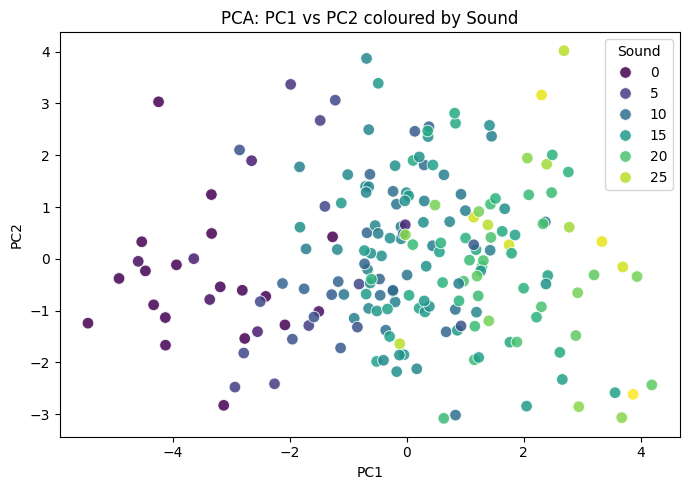

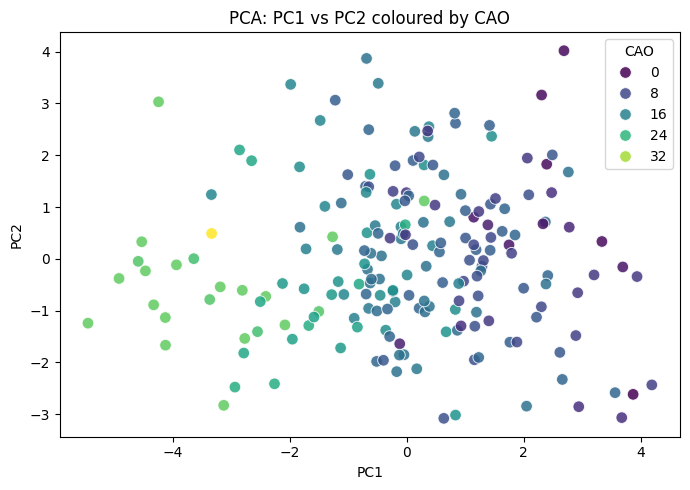

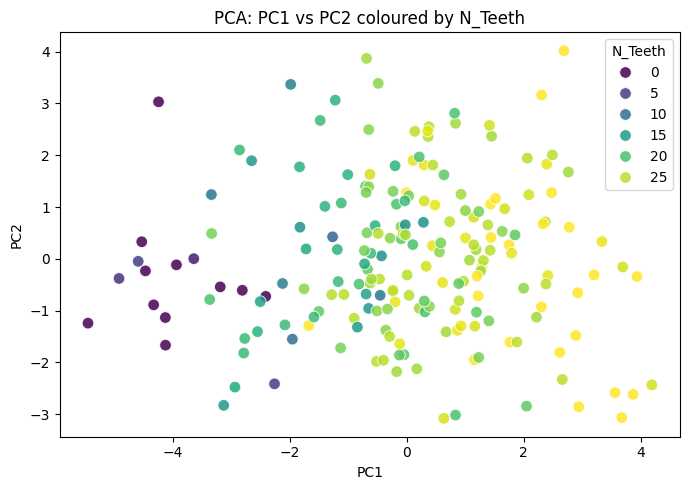

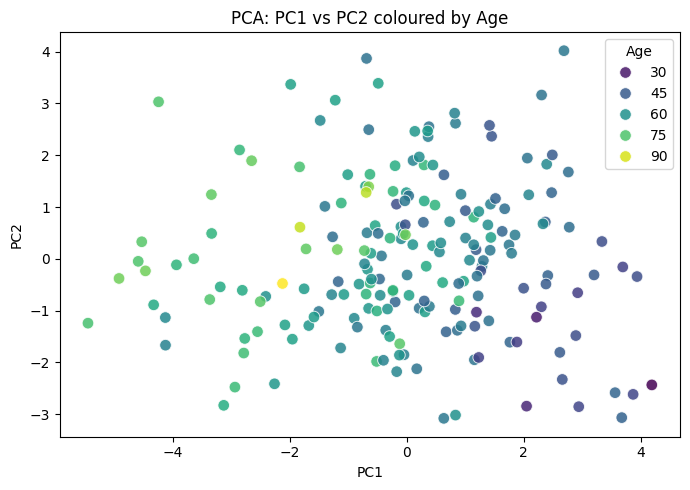

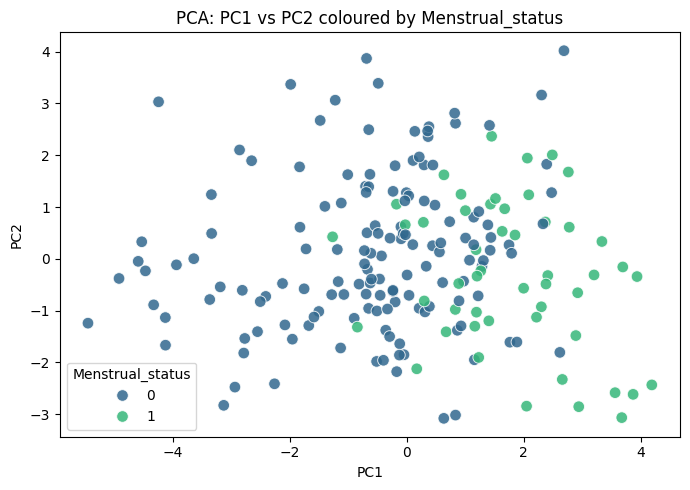

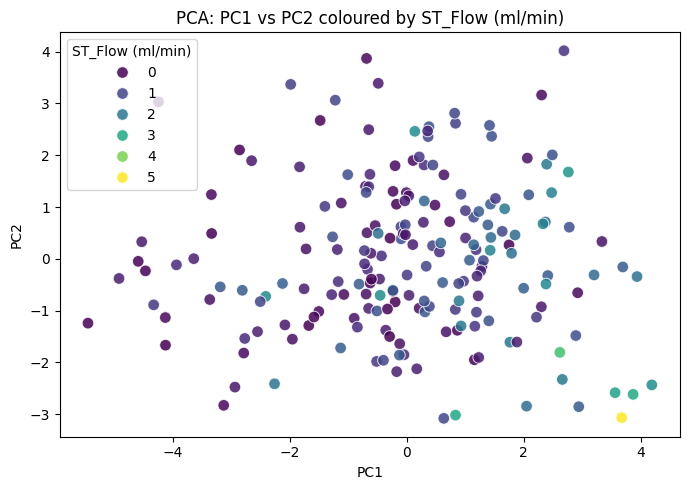

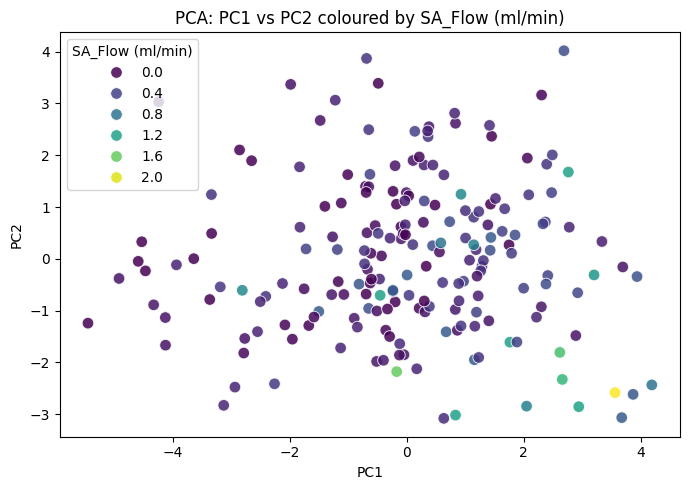

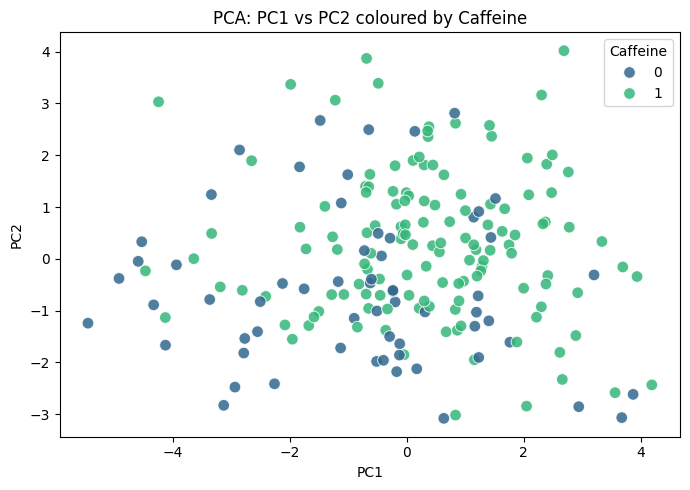

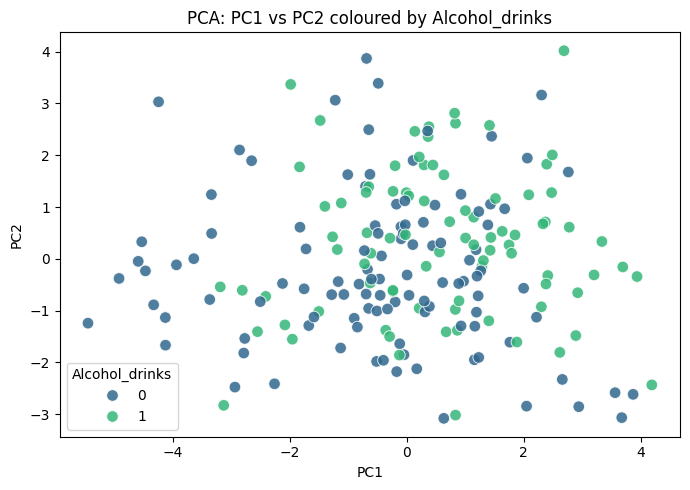

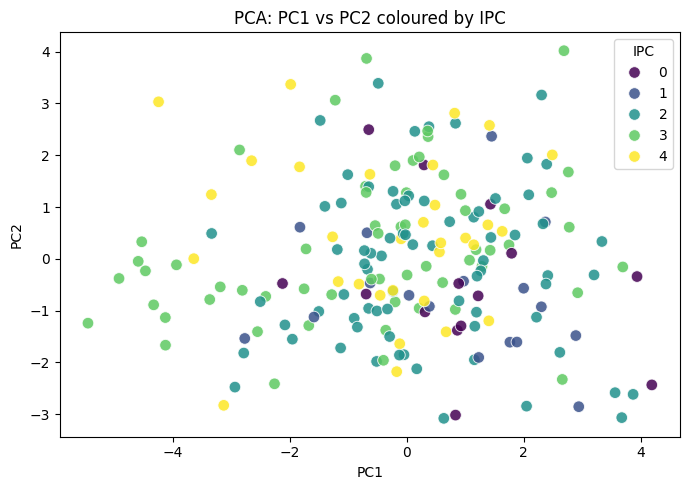

In [8]:
def plot_pc_scatter(variables, mark_diagnosis=False):
    # PC1 vs PC2 scatter coloured by each variable in turn.
    plot_df = data.join(pc_scores)
    style_kwargs = dict(style=TARGET, markers={0: "o", 1: "X"}) if mark_diagnosis else {}
    for var in variables:
        fig, ax = plt.subplots(figsize=(7, 5))
        sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue=var, palette="viridis",
                        s=70, alpha=0.85, ax=ax, **style_kwargs)
        ax.set_title(f"PCA: PC1 vs PC2 coloured by {var}")
        fig.tight_layout()
        plt.show()


plot_pc_scatter(pc1_assoc["variable"].head(10))

The PCA projection confirms that the dominant structure of the data (the PC1 axis) reflects biological and oral
ageing: advanced age, loss of healthy teeth (`Sound`) and reduced stimulated salivary flow (`ST_Flow`) overlap almost
completely.

### 1.2 Association with PC2

We repeat the association scan for the second principal component to identify the phenomena behind the second
axis of variance.

In [9]:
pc2_assoc = scan_associations(pca_features, pc_scores["PC2"])
print("Top 10 variables associated with PC2:")
display(pc2_assoc.head(10))

Top 10 variables associated with PC2:


,variable,method,score,r,p_value
0,Former_cigarettes/day,pearson,0.566313,0.566313,5.118861e-18
1,Cardiovascular,pearson,0.561130,0.561130,1.185507e-17
2,Diabetes,pearson,0.484286,0.484286,6.401562e-13
3,Hyposalivation_med,pearson,0.481827,0.481827,8.688346e-13
4,Smoking,pearson,0.427745,0.427745,4.019688e-10
5,Special_Diet,pearson,0.379192,-0.379192,4.234054e-08
6,Gastrointestinal,pearson,0.364536,0.364536,1.498542e-07
7,Sugar_between meals,pearson,0.347327,0.347327,6.112269e-07
8,SA_Flow (ml/min),pearson,0.280411,-0.280411,6.868253e-05
9,Caffeine,pearson,0.279083,0.279083,7.458642e-05


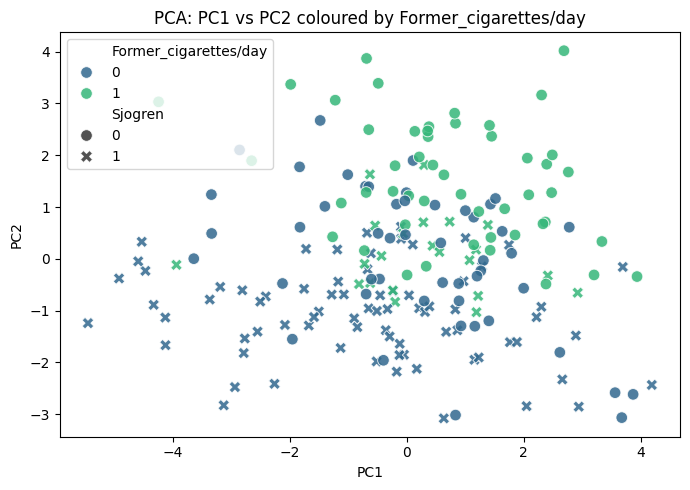

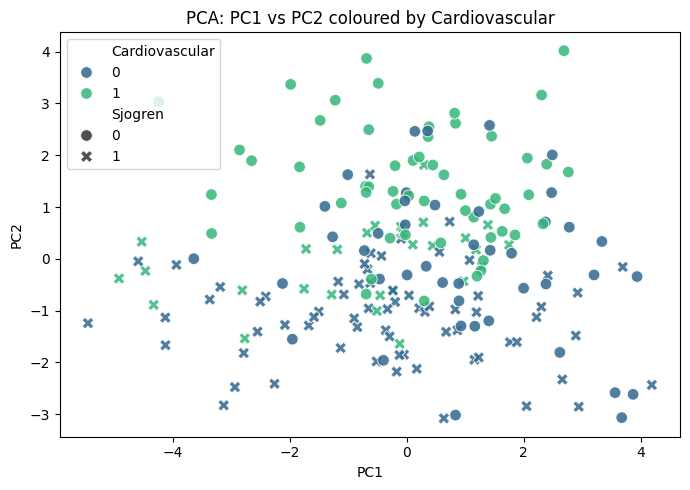

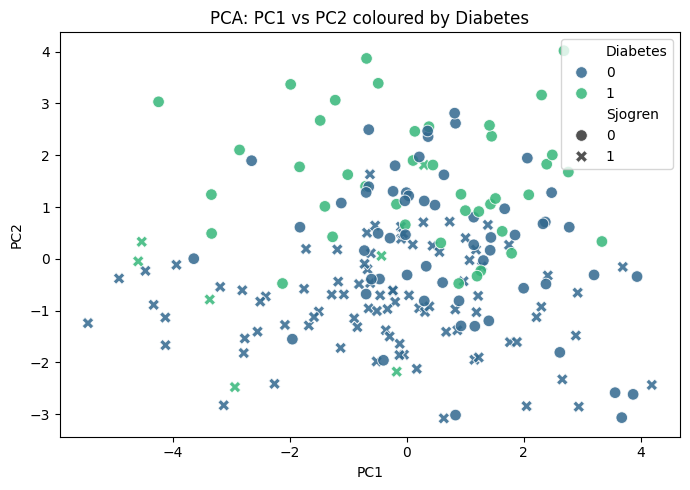

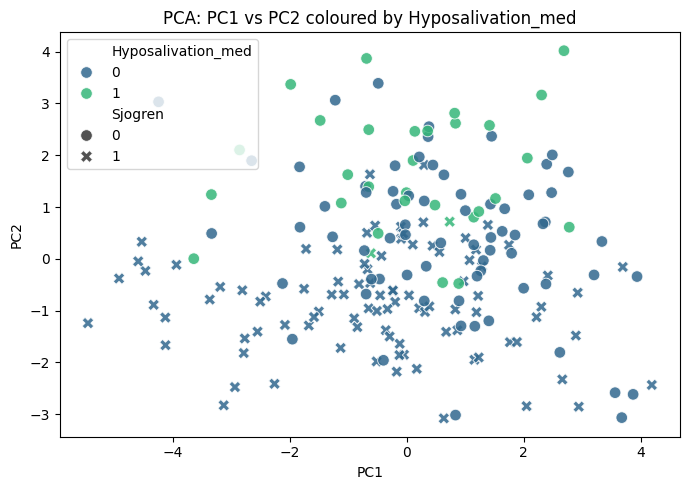

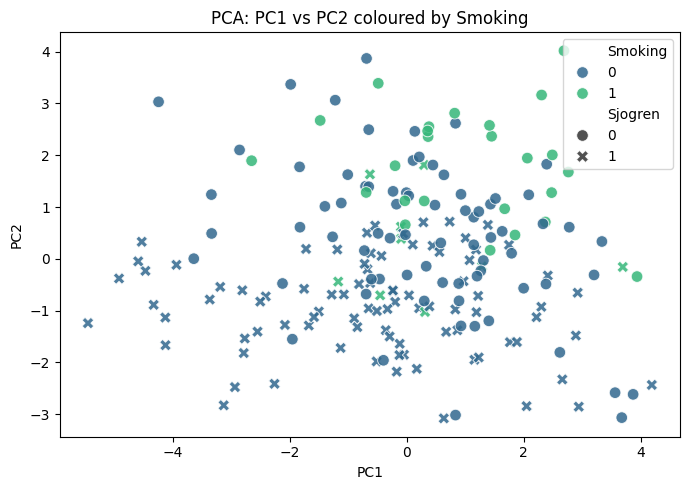

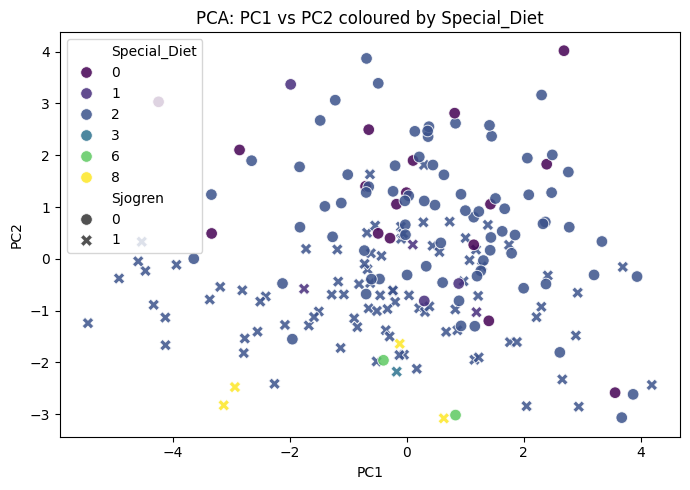

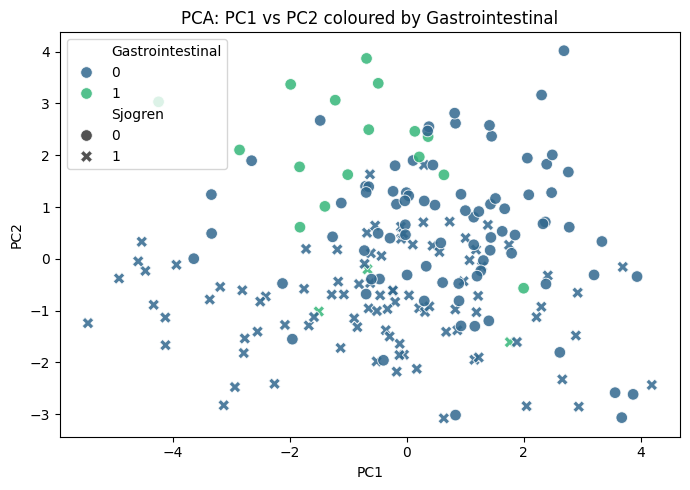

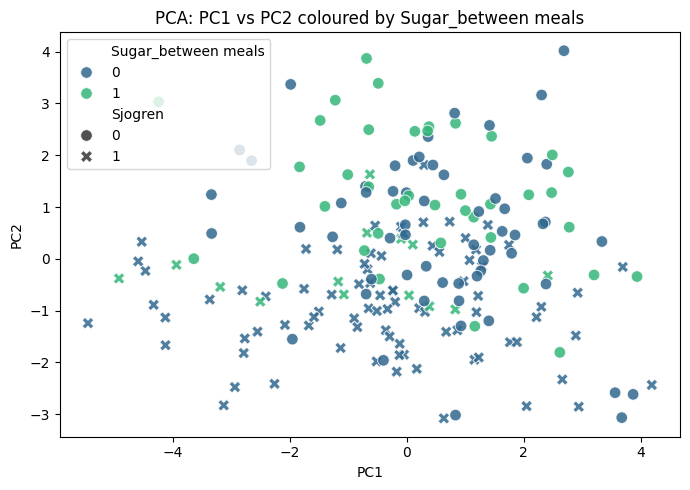

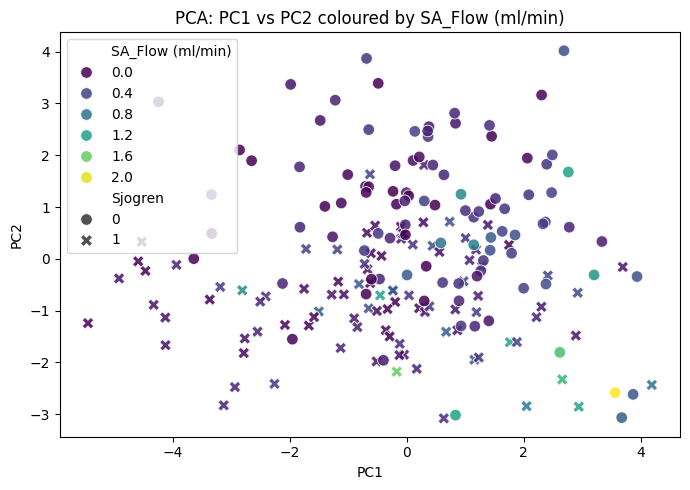

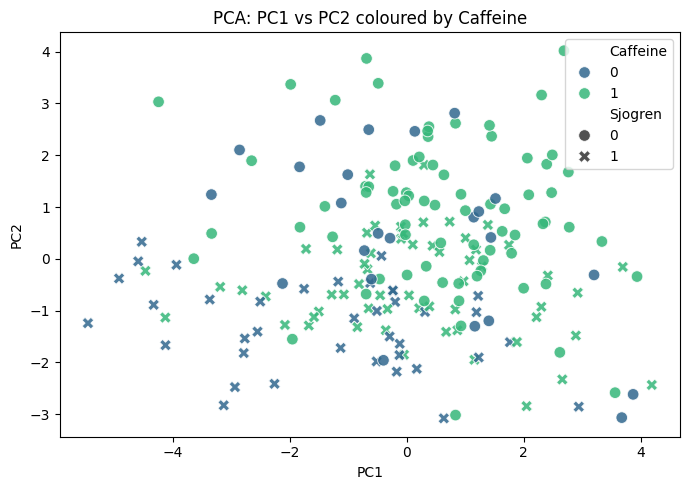

In [10]:
plot_pc_scatter(pc2_assoc["variable"].head(10), mark_diagnosis=True)

PC2 is driven by metabolic and pharmacological factors (smoking history, cardiovascular disease, diabetes,
hyposalivation-inducing medication), most of which are more frequent among controls. PC2 is also the component most
strongly associated with the diagnosis, meaning that part of the apparent SjS/control separation in the latent space
is carried by these confounders.

## 2. Supervised analysis: what does the classifier rely on?

A Random Forest is trained to predict the diagnosis, and SHAP values are used to explain its decisions. If variables
that are consequences of the disease or its treatment (e.g. corticosteroids, immunosuppressants, hyposalivation
medication) rank highest, the model is exploiting information leakage rather than learning disease biology. We
therefore retrain the model after progressively removing groups of confounders:

| Model | Features |
|---|---|
| Full | all variables |
| Without comorbidities | full − diabetes, cardiovascular disease, hyposalivation medication |
| Without oral variables | full − dental and salivary variables |
| Biological | oral and salivary variables only (all leakage, demographic and lifestyle variables removed) |

All models use the same stratified 80/20 split and 5-fold cross-validation (`random_state = 42`).

In [11]:
@dataclass
class RFResult:
    name: str
    model: RandomForestClassifier
    X_train: pd.DataFrame
    X_test: pd.DataFrame
    y_train: pd.Series
    y_test: pd.Series
    y_pred: np.ndarray
    y_proba: np.ndarray
    fpr: np.ndarray
    tpr: np.ndarray
    roc_auc: float
    cv_scores: np.ndarray
    shap_values: shap.Explanation  # SHAP values for the positive class (SjS)

    @property
    def test_accuracy(self):
        return accuracy_score(self.y_test, self.y_pred)


def run_rf_experiment(X, y, name):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)

    cv_scores = cross_val_score(RandomForestClassifier(random_state=RANDOM_STATE),
                                X, y, cv=CV_FOLDS, scoring="accuracy")

    model = RandomForestClassifier(random_state=RANDOM_STATE).fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)

    shap_values = shap.Explainer(model, X_train)(X_test, check_additivity=False)[..., 1]

    result = RFResult(name, model, X_train, X_test, y_train, y_test, y_pred, y_proba,
                      fpr, tpr, auc(fpr, tpr), cv_scores, shap_values)
    print(f"{name} ({X.shape[1]} features)\n"
          f"  {CV_FOLDS}-fold CV accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}\n"
          f"  Test accuracy:        {result.test_accuracy:.3f}\n"
          f"  Test ROC AUC:         {result.roc_auc:.3f}")
    return result


def plot_rf_diagnostics(result):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(result.fpr, result.tpr, label=f"AUC = {result.roc_auc:.2f}")
    ax.plot([0, 1], [0, 1], "k--")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"ROC curve — Random Forest ({result.name})")
    ax.legend()
    fig.tight_layout()
    plt.show()

    shap.plots.bar(result.shap_values)
    shap.summary_plot(result.shap_values, result.X_test, plot_type="dot")

### 2.1 Full model

Full model (25 features)
  5-fold CV accuracy: 0.832 ± 0.057
  Test accuracy:        0.775
  Test ROC AUC:         0.916


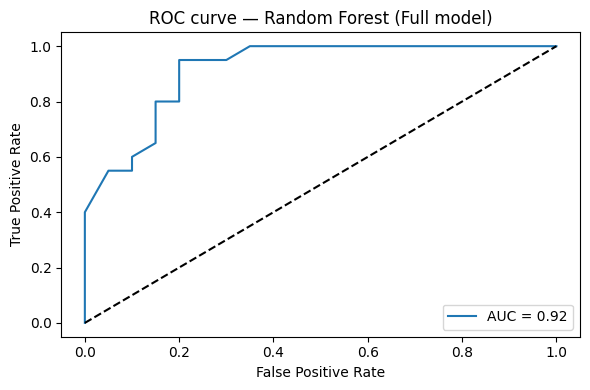

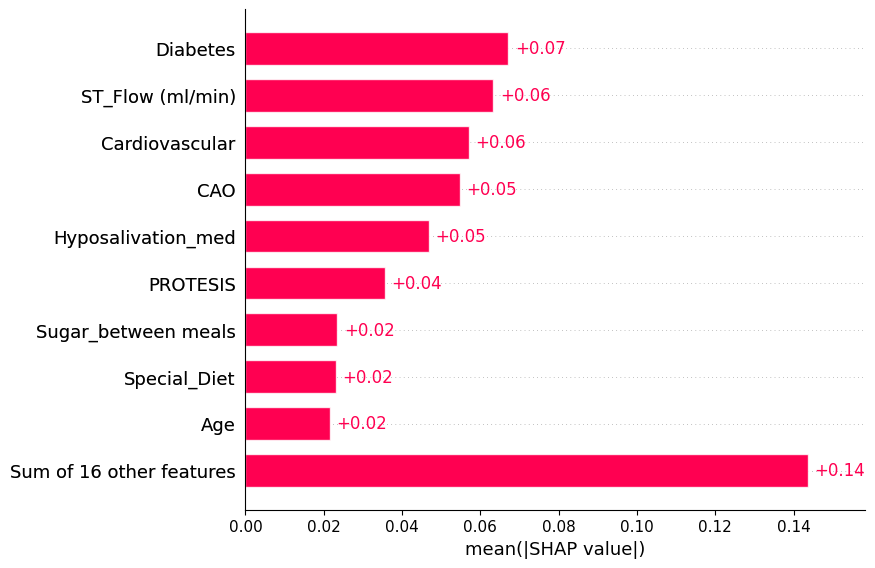

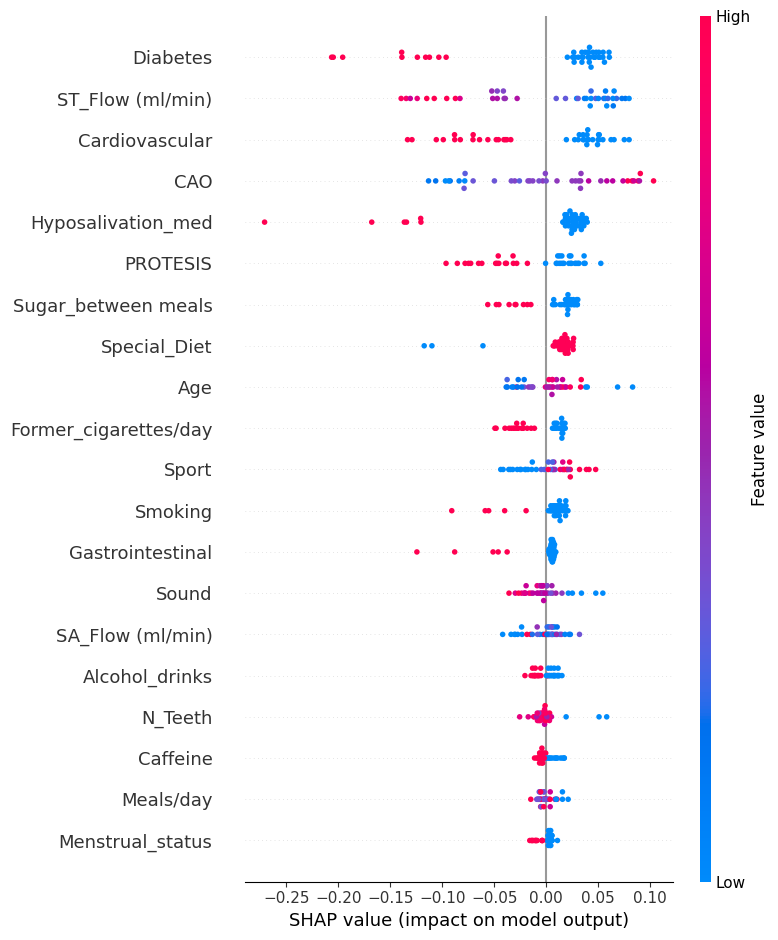

In [12]:
y = data[TARGET]
X_full = data.drop(columns=TARGET)

rf_full = run_rf_experiment(X_full, y, "Full model")
plot_rf_diagnostics(rf_full)

Saved figures\rf_full_first_tree.pdf / .png


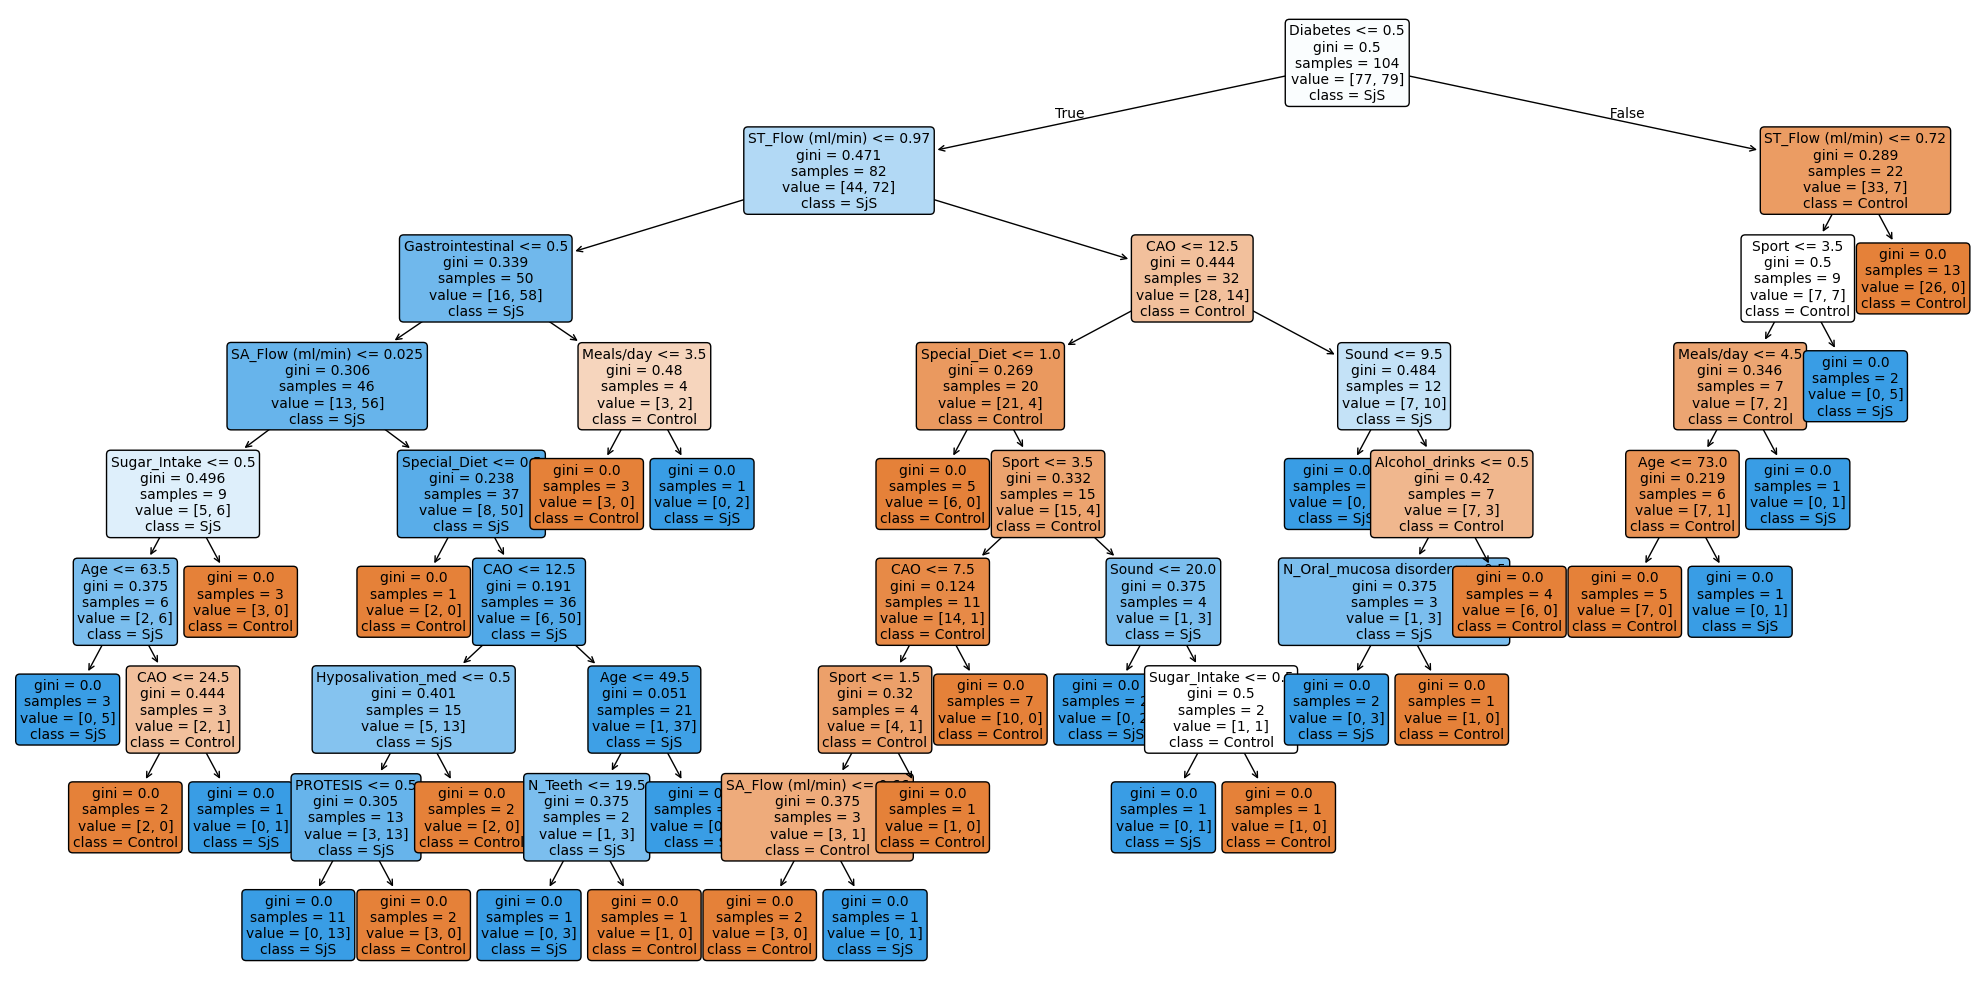

In [13]:
fig = plt.figure(figsize=(20, 10))
plot_tree(rf_full.model.estimators_[0], feature_names=X_full.columns,
          class_names=["Control", "SjS"], filled=True, rounded=True, fontsize=10)
fig.tight_layout()
save_figure(fig, "rf_full_first_tree")
plt.show()

### 2.2 Without comorbidities

Without comorbidities (22 features)
  5-fold CV accuracy: 0.745 ± 0.049
  Test accuracy:        0.800
  Test ROC AUC:         0.919


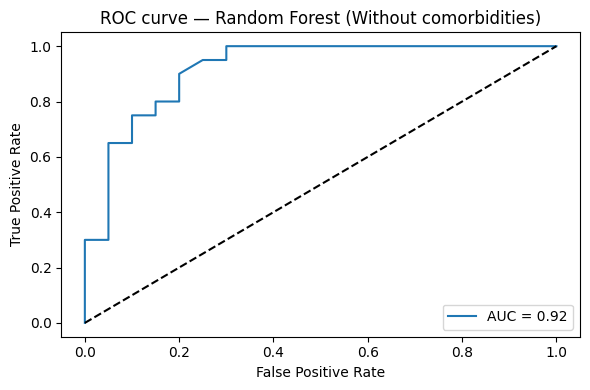

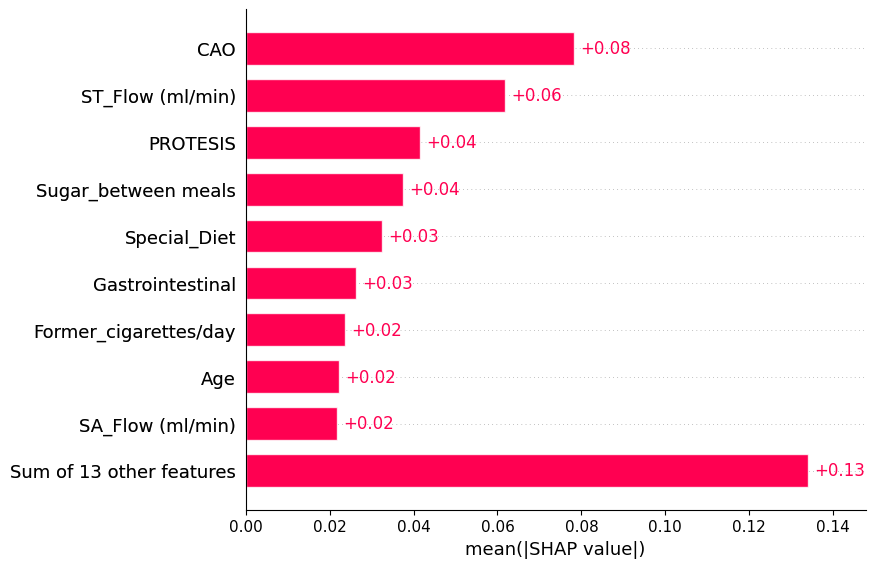

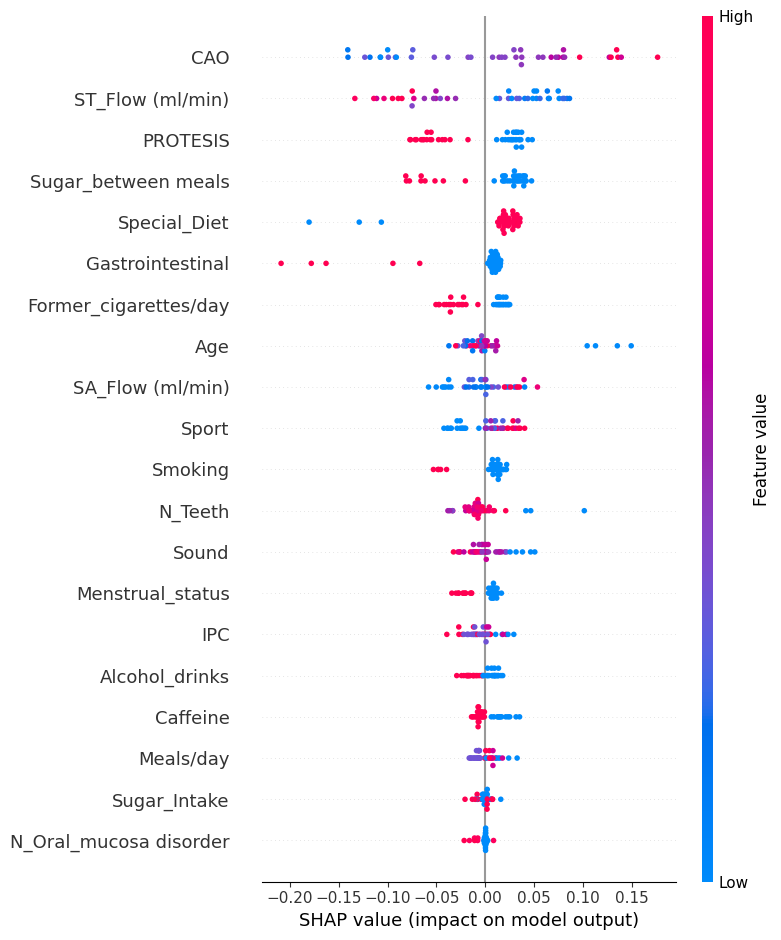

In [14]:
rf_no_comorb = run_rf_experiment(X_full.drop(columns=COMORBIDITY_VARS), y, "Without comorbidities")
plot_rf_diagnostics(rf_no_comorb)

### 2.3 Without oral and salivary variables

Without oral variables (17 features)
  5-fold CV accuracy: 0.791 ± 0.091
  Test accuracy:        0.725
  Test ROC AUC:         0.776


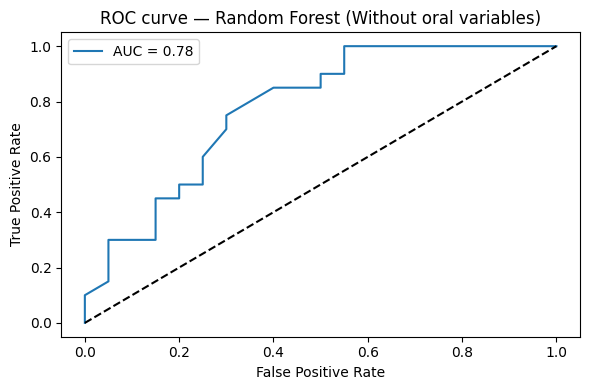

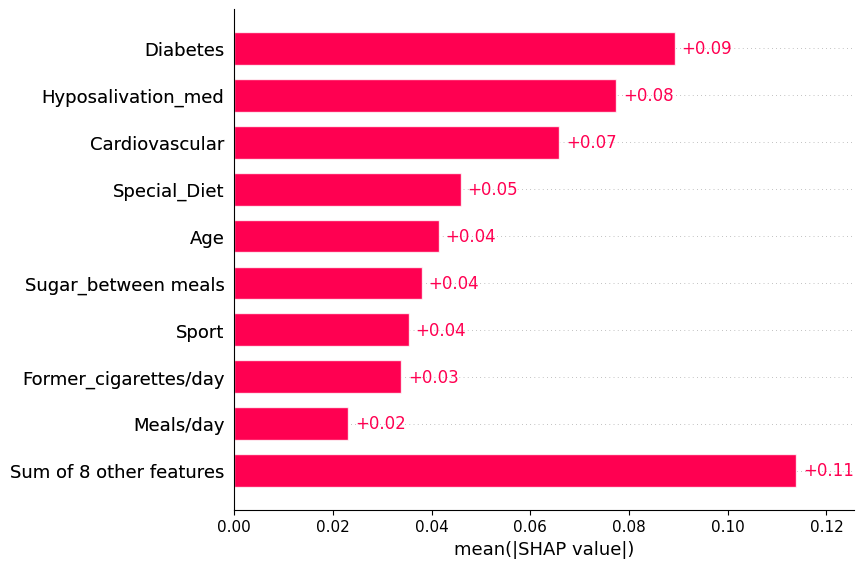

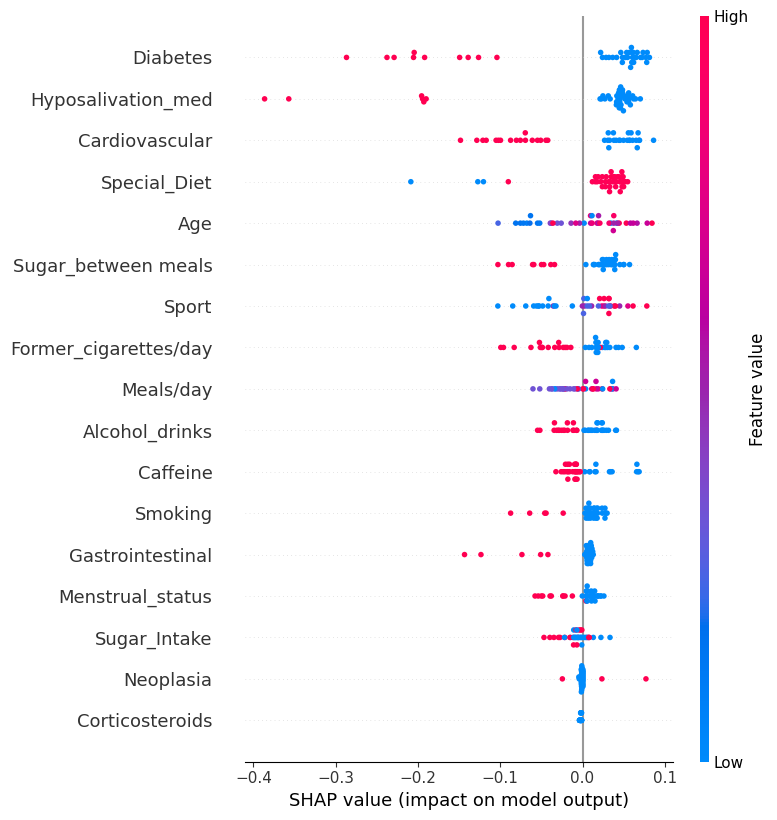

In [15]:
rf_no_oral = run_rf_experiment(X_full.drop(columns=ORAL_VARS), y, "Without oral variables")
plot_rf_diagnostics(rf_no_oral)

### 2.4 Biological model

All variables that are a consequence of the disease or its treatment (information leakage), demographic variables
and lifestyle variables are removed, leaving only oral and salivary measurements.

Removed 17 variables: ['Diabetes', 'Cardiovascular', 'Hyposalivation_med', 'Corticosteroids', 'Gastrointestinal', 'Neoplasia', 'Age', 'Menstrual_status', 'Sport', 'Smoking', 'Former_cigarettes/day', 'Alcohol_drinks', 'Caffeine', 'Sugar_between meals', 'Sugar_Intake', 'Special_Diet', 'Meals/day']
Remaining 8 features: ['N_Teeth', 'Sound', 'CAO', 'PROTESIS', 'N_Oral_mucosa disorder', 'SA_Flow (ml/min)', 'ST_Flow (ml/min)', 'IPC']

Biological model (8 features)
  5-fold CV accuracy: 0.664 ± 0.061
  Test accuracy:        0.700
  Test ROC AUC:         0.820


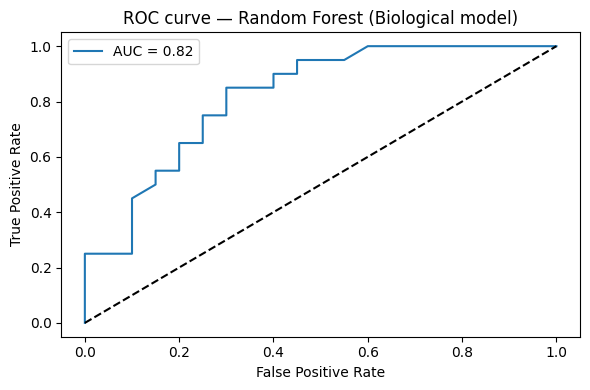

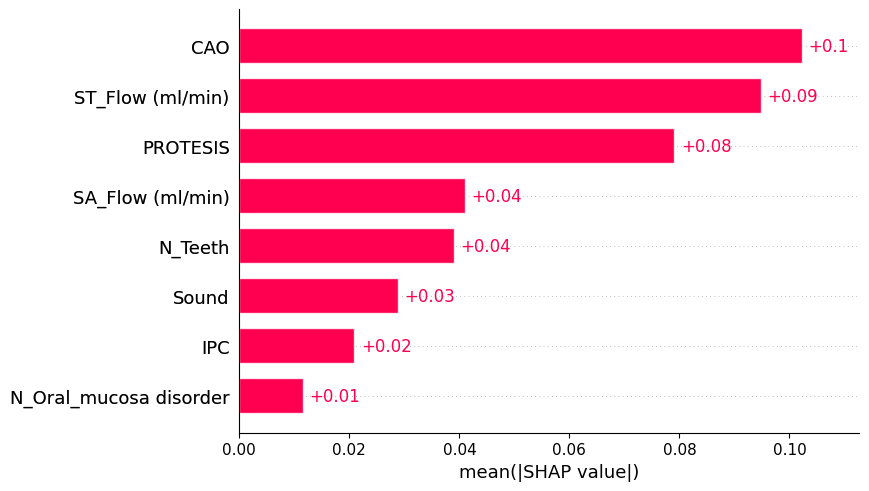

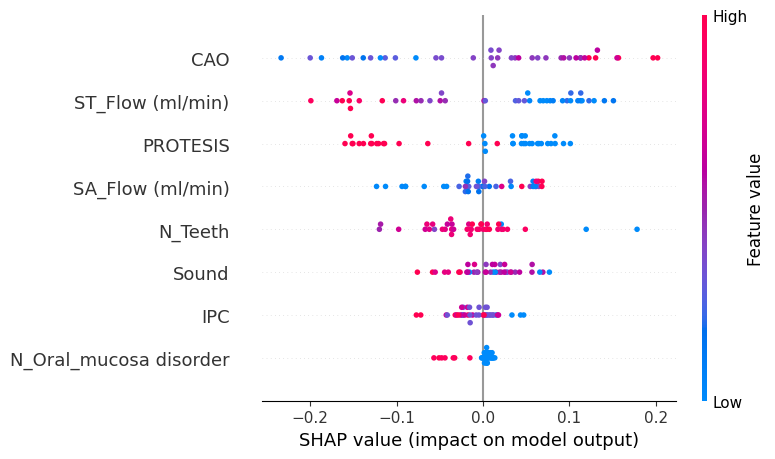

In [16]:
excluded = [col for block in CONFOUNDER_BLOCKS.values() for col in block if col in X_full.columns]
X_bio = X_full.drop(columns=excluded)

print(f"Removed {len(excluded)} variables: {excluded}")
print(f"Remaining {X_bio.shape[1]} features: {X_bio.columns.tolist()}\n")

rf_bio = run_rf_experiment(X_bio, y, "Biological model")
plot_rf_diagnostics(rf_bio)

**Accuracy of the biological model by age group.** Out-of-fold predictions from 5-fold cross-validation are
stratified by age to check whether the model's performance depends on patient age.

In [17]:
AGE_BINS = [0, 40, 50, 60, 70, 100]
AGE_LABELS = ["<40", "40–50", "50–60", "60–70", ">70"]

y_pred_cv = cross_val_predict(RandomForestClassifier(random_state=RANDOM_STATE),
                              X_bio, y, cv=CV_FOLDS)
cv_by_age = pd.DataFrame({
    "age_group": pd.cut(data["Age"], bins=AGE_BINS, labels=AGE_LABELS),
    "correct": (y.values == y_pred_cv).astype(int),
})
accuracy_by_age = (cv_by_age.groupby("age_group", observed=True)["correct"]
                   .agg(accuracy="mean", n="count").reset_index())
overall_cv_accuracy = cv_by_age["correct"].mean()

print(f"Overall out-of-fold accuracy: {overall_cv_accuracy:.3f}")
display(accuracy_by_age.style.format({"accuracy": "{:.1%}"}))

Overall out-of-fold accuracy: 0.663


,age_group,accuracy,n
0,<40,45.5%,11
1,40–50,60.0%,40
2,50–60,68.8%,64
3,60–70,72.5%,51
4,>70,66.7%,30


## 3. Hormonal and age effects on stimulated salivary flow

### 3.1 Does menopausal status affect salivary flow?

To separate the hormonal effect from ageing, we compare pre- and post-menopausal women within a narrow age window
(45–55 years), separately for each diagnostic group (Welch's t-test).

In [18]:
window = data[data["Age"].between(*MENOPAUSE_WINDOW)].copy()
window["postmenopausal"] = window["Menstrual_status"] == 1
print(f"Participants aged {MENOPAUSE_WINDOW[0]}–{MENOPAUSE_WINDOW[1]}: {len(window)}")

menopause_flow = {}
rows = []
for group, label in [(1, "SjS"), (0, "Control")]:
    subset = window[window[TARGET] == group]
    pre = subset.loc[~subset["postmenopausal"], ST_FLOW].dropna()
    post = subset.loc[subset["postmenopausal"], ST_FLOW].dropna()
    p = ttest_ind(pre, post, equal_var=False).pvalue if min(len(pre), len(post)) >= 3 else np.nan
    menopause_flow[label] = dict(pre=pre, post=post, p=p)
    rows.append(dict(group=label, n_pre=len(pre), mean_pre=pre.mean(),
                     n_post=len(post), mean_post=post.mean(), p_value=p))

display(pd.DataFrame(rows).round(4))

Participants aged 45–55: 64


,group,n_pre,mean_pre,n_post,mean_post,p_value
0,SjS,16,0.4425,7,0.6500,0.3074
1,Control,19,1.1342,22,1.4864,0.2544


Within the 45–55 window, stimulated flow does not differ significantly between pre- and post-menopausal women in either
group. Even among premenopausal women, SjS patients have less than half the stimulated flow of controls, which suggests
that the reduction is driven by the disease rather than by hormonal ageing.

### 3.2 How does age affect salivary flow in each group?

We fit a linear regression of stimulated flow on age within each group, test whether the slopes differ
(age × diagnosis interaction) and compare groups within age strata.

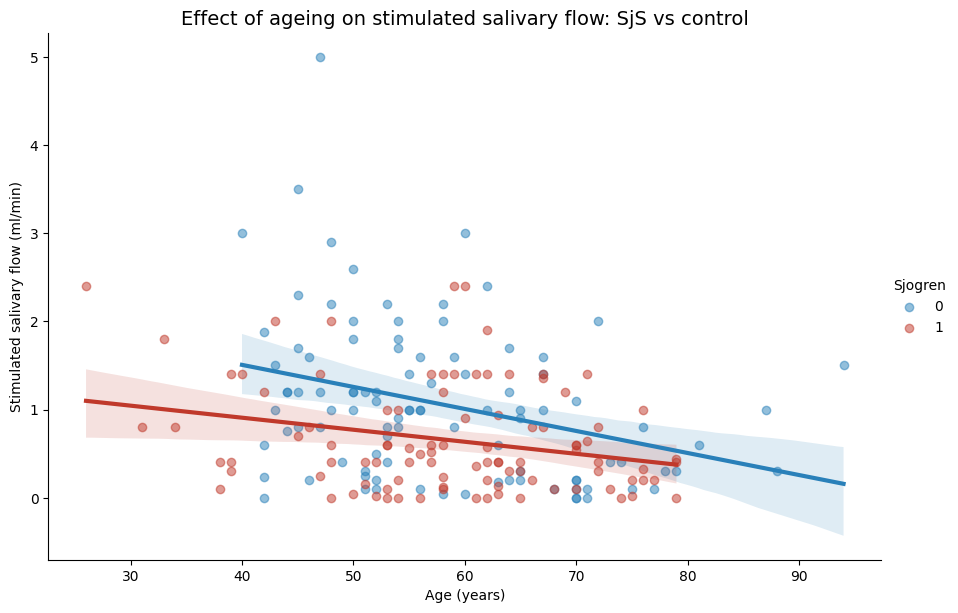

,group,n,slope,intercept,r2,p_value
0,SjS,97,-0.0137,1.4538,0.0707,0.0085
1,Control,99,-0.0250,2.5065,0.1068,0.0010


In [19]:
age_flow = data[["Age", ST_FLOW, TARGET]].dropna()

grid = sns.lmplot(data=age_flow, x="Age", y=ST_FLOW, hue=TARGET,
                  palette={0: COLORS["control"], 1: COLORS["sjogren"]}, height=6, aspect=1.5,
                  scatter_kws={"alpha": 0.5}, line_kws={"linewidth": 3})
grid.ax.set_title("Effect of ageing on stimulated salivary flow: SjS vs control", fontsize=14)
grid.set_axis_labels("Age (years)", "Stimulated salivary flow (ml/min)")
plt.show()

age_slopes = {}
for group, label in [(1, "SjS"), (0, "Control")]:
    subset = age_flow[age_flow[TARGET] == group]
    fit = linregress(subset["Age"], subset[ST_FLOW])
    age_slopes[group] = dict(group=label, n=len(subset), slope=fit.slope, intercept=fit.intercept,
                             r2=fit.rvalue ** 2, p_value=fit.pvalue)
display(pd.DataFrame(age_slopes.values()).round(4))

In [20]:
interaction_df = age_flow.rename(columns={ST_FLOW: "Flow"})
interaction_model = ols(f"Flow ~ Age + C({TARGET}) + Age:C({TARGET})", data=interaction_df).fit()
print("Age × diagnosis interaction model")
print(interaction_model.summary().tables[1])

STRATA_BINS = [0, 50, 70, 100]
STRATA_LABELS = ["<50", "50–70", ">70"]
age_flow_strata = age_flow.assign(age_group=pd.cut(age_flow["Age"], bins=STRATA_BINS, labels=STRATA_LABELS))

flow_by_stratum = {}
rows = []
for stratum in STRATA_LABELS:
    subset = age_flow_strata[age_flow_strata["age_group"] == stratum]
    ctrl = subset.loc[subset[TARGET] == 0, ST_FLOW]
    sjs = subset.loc[subset[TARGET] == 1, ST_FLOW]
    p = ttest_ind(ctrl, sjs, equal_var=False).pvalue if min(len(ctrl), len(sjs)) > 1 else np.nan
    flow_by_stratum[stratum] = dict(ctrl=ctrl, sjs=sjs, p=p)
    rows.append(dict(age_group=stratum, n_control=len(ctrl), mean_control=ctrl.mean(),
                     n_sjs=len(sjs), mean_sjs=sjs.mean(),
                     difference=ctrl.mean() - sjs.mean(), p_value=p))

print("\nStimulated flow by age stratum (Welch's t-test)")
display(pd.DataFrame(rows).round(4))

Age × diagnosis interaction model
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               2.5065      0.373      6.716      0.000       1.770       3.243
C(Sjogren)[T.1]        -1.0527      0.530     -1.984      0.049      -2.099      -0.006
Age                    -0.0250      0.006     -3.951      0.000      -0.037      -0.013
Age:C(Sjogren)[T.1]     0.0113      0.009      1.268      0.206      -0.006       0.029

Stimulated flow by age stratum (Welch's t-test)


,age_group,n_control,mean_control,n_sjs,mean_sjs,difference,p_value
0,<50,30,1.5327,21,0.9138,0.6189,0.0172
1,50–70,55,0.9293,60,0.6312,0.2981,0.0174
2,>70,14,0.5643,16,0.4012,0.1630,0.3840


**Age vs flow regression.** The SjS group shows a flatter age slope and a lower intercept than controls, consistent
with a *floor effect*: hyposalivation is an early and stable feature of the disease, and ageing adds little further
damage because glandular function is already compromised. In controls, flow declines more steeply with age,
consistent with the progressive impact of ageing and accumulated metabolic factors (Section 1). Note, however, that
the difference between slopes is not statistically significant (age × diagnosis interaction term).

Stratified comparisons show that the SjS–control difference is significant in younger and middle-aged participants
but not in those over 70, where both groups converge towards low flow. Age therefore confounds the diagnosis mainly in
older patients, whereas in younger and middle-aged patients hyposalivation remains a clear marker of the disease.

### 3.3 Does salivary flow decrease with time since menopause?

Years since menopause are computed as current age minus age at last menstruation. If the SjS trajectory is already low
at year 0, the reduction is attributable to the disease; a progressive decline with years since menopause in controls
would indicate a hormonal effect.

In [21]:
menstruation = (
    pd.read_excel(MENSTRUATION_DATA)
    .rename(columns={"CÓDIGO PACIENTE/CONTROL": "SubjectID",
                     "Edad de su última menstruación": "age_last_menstruation"})
    [["SubjectID", "age_last_menstruation"]]
    .assign(SubjectID=lambda d: d["SubjectID"].astype(str))
)

duplicated_ids = menstruation.loc[menstruation["SubjectID"].duplicated(keep=False), "SubjectID"].unique()
if len(duplicated_ids):
    print(f"Warning: duplicated IDs in {MENSTRUATION_DATA.name} (first occurrence kept): {list(duplicated_ids)}")
menstruation = menstruation.drop_duplicates("SubjectID", keep="first")

hormonal = data.assign(SubjectID=subject_ids.values).merge(
    menstruation, on="SubjectID", how="left", validate="many_to_one")
assert len(hormonal) == len(data)

# Non-numeric entries (e.g. "PRE" for premenopausal women) become NaN
hormonal["age_last_menstruation"] = pd.to_numeric(hormonal["age_last_menstruation"], errors="coerce")
hormonal["years_since_menopause"] = hormonal["Age"] - hormonal["age_last_menstruation"]

postmenopausal = hormonal.dropna(subset=["years_since_menopause", ST_FLOW])
postmenopausal = postmenopausal[postmenopausal["years_since_menopause"] >= 0]

print(f"Missing age at last menstruation: {hormonal['age_last_menstruation'].isna().sum()}")
print(f"Participants included: {len(postmenopausal)}")

Missing age at last menstruation: 61
Participants included: 122


Pearson r    = -0.204 (p = 0.0241)
Spearman rho = -0.190 (p = 0.0363)


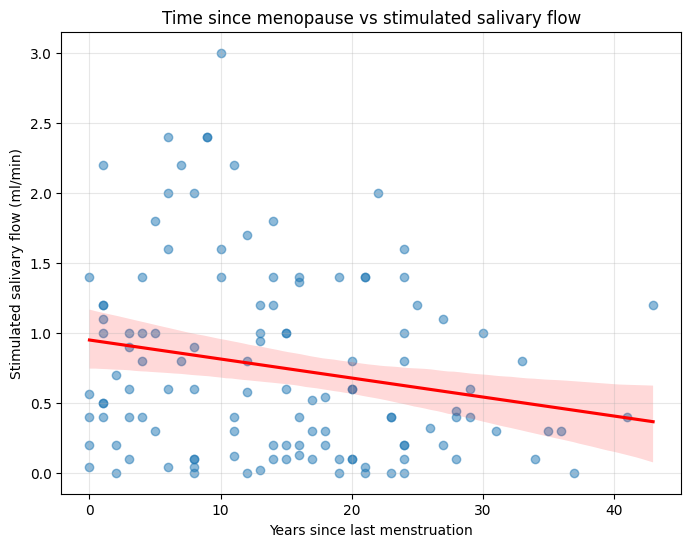

In [22]:
r_p, p_p = pearsonr(postmenopausal["years_since_menopause"], postmenopausal[ST_FLOW])
rho_s, p_s = spearmanr(postmenopausal["years_since_menopause"], postmenopausal[ST_FLOW])
print(f"Pearson r    = {r_p:.3f} (p = {p_p:.4f})")
print(f"Spearman rho = {rho_s:.3f} (p = {p_s:.4f})")

fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(data=postmenopausal, x="years_since_menopause", y=ST_FLOW,
            scatter_kws={"alpha": 0.5}, line_kws={"color": "red"}, ax=ax)
ax.set_title("Time since menopause vs stimulated salivary flow")
ax.set_xlabel("Years since last menstruation")
ax.set_ylabel("Stimulated salivary flow (ml/min)")
ax.grid(True, alpha=0.3)
plt.show()

Although the decline is statistically significant, the correlation is weak. This suggests that:

1. the decline most likely reflects ageing itself (more years since menopause implies greater chronological age)
   rather than a cumulative effect of hormone deprivation;
2. the large dispersion around year 0 indicates that other factors, such as the disease or medication, are the main
   determinants of flow, far outweighing time since menopause.

### 3.4 Multivariable analysis of salivary flow determinants

An ordinary least squares model quantifies the independent contribution of the diagnosis, age and
hyposalivation-inducing medication to stimulated flow, each adjusted for the others.

In [23]:
ols_data = data[[ST_FLOW, "Age", TARGET, "Hyposalivation_med"]].dropna()
flow_model = sm.OLS(ols_data[ST_FLOW],
                    sm.add_constant(ols_data[[TARGET, "Age", "Hyposalivation_med"]])).fit()
print(flow_model.summary())

beta = flow_model.params
age_equivalent_years = abs(beta[TARGET]) / abs(beta["Age"])
print(f"\nSjS effect:        {beta[TARGET]:+.3f} ml/min")
print(f"Medication effect: {beta['Hyposalivation_med']:+.3f} ml/min")
print(f"Age effect:        {beta['Age'] * 10:+.3f} ml/min per decade")
print(f"SjS effect expressed as years of ageing: {age_equivalent_years:.1f}")

                            OLS Regression Results                            
Dep. Variable:       ST_Flow (ml/min)   R-squared:                       0.187
Model:                            OLS   Adj. R-squared:                  0.174
Method:                 Least Squares   F-statistic:                     14.71
Date:                Thu, 24 Sep 2026   Prob (F-statistic):           1.17e-08
Time:                        11:57:54   Log-Likelihood:                -210.25
No. Observations:                 196   AIC:                             428.5
Df Residuals:                     192   BIC:                             441.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  2.2512      0

The adjusted model establishes the following hierarchy of effects on stimulated flow (ceteris paribus):

- **Autoimmune disease.** The SjS diagnosis is the main determinant, reducing stimulated flow relative to a control of
  the same age and medication status.
- **Pharmacological effect.** Hyposalivation-inducing medication produces a reduction of similar magnitude. This
  similarity explains the diagnostic difficulty in polymedicated controls.
- **Ageing.** Age contributes a progressive decline per decade.

Although age is significant, the functional damage caused by the disease (or by medication in controls) far exceeds
that of natural age-related atrophy. Expressed in terms of the age coefficient, the effect of the diagnosis is
equivalent to several decades of ageing; this is a coefficient-based heuristic, not a biological estimate.

## 4. Publication figures

### Figure 2 — Latent structure of the dataset (PCA)

Panels use the PCA fitted in Section 1.

Saved figures\fig2_panel_A.pdf / .png


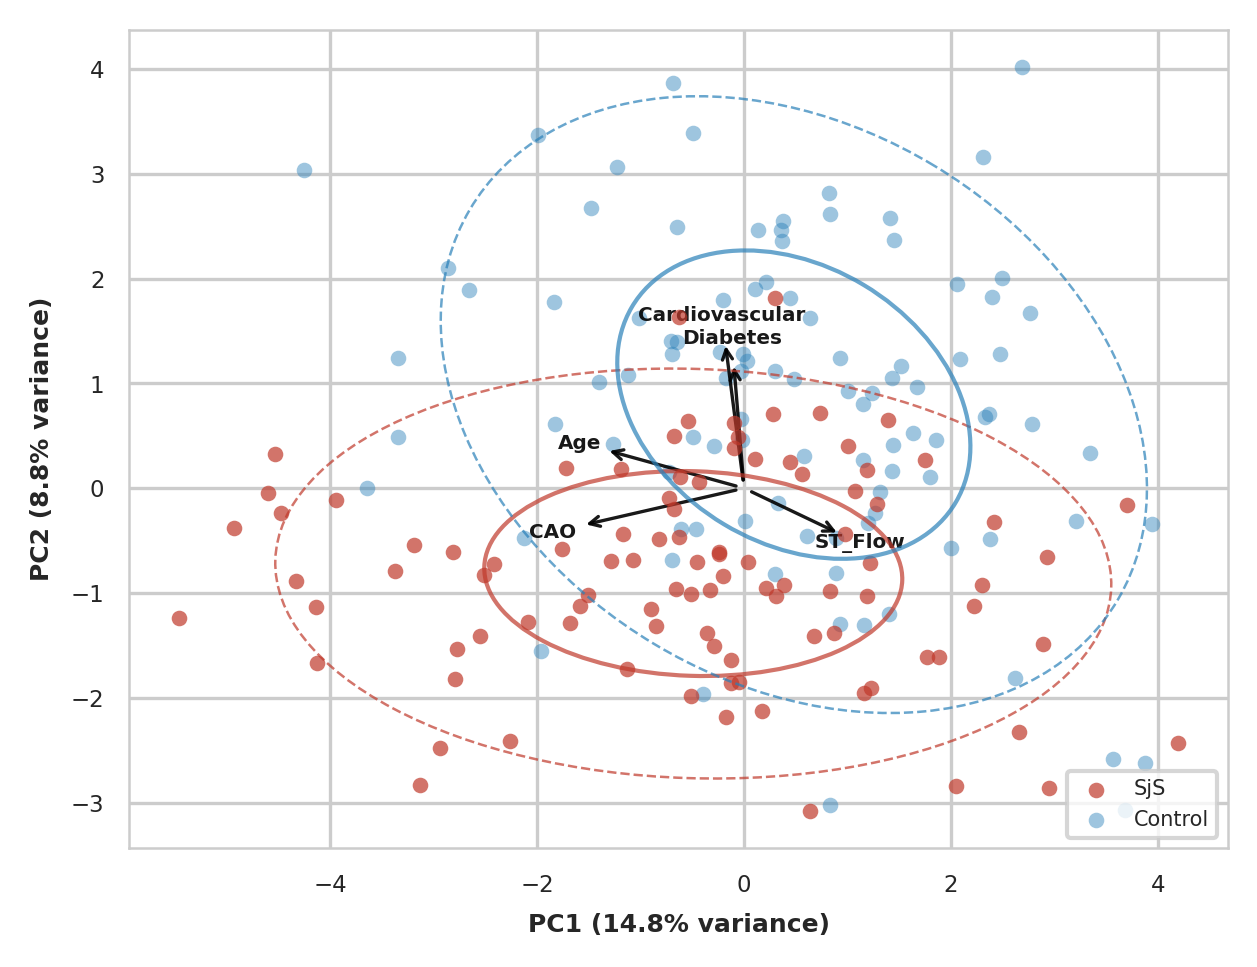

In [24]:
is_sjs = (data[TARGET] == 1).values
sjs_pc1, sjs_pc2 = pc_scores.loc[is_sjs, "PC1"].values, pc_scores.loc[is_sjs, "PC2"].values
ctrl_pc1, ctrl_pc2 = pc_scores.loc[~is_sjs, "PC1"].values, pc_scores.loc[~is_sjs, "PC2"].values

# Panel A — PCA biplot
BIPLOT_VARS = {"Age": "Age", "CAO": "CAO", ST_FLOW: "ST_Flow",
               "Cardiovascular": "Cardiovascular", "Diabetes": "Diabetes"}
ARROW_SCALE = 3.8

with publication_style():
    fig, ax = plt.subplots(figsize=(120 * MM, 90 * MM), dpi=300)
    fig.patch.set_facecolor("white")

    ax.scatter(sjs_pc1, sjs_pc2, color=COLORS["sjogren"], marker="o", s=14,
               alpha=0.7, zorder=4, lw=0, label="SjS")
    ax.scatter(ctrl_pc1, ctrl_pc2, color=COLORS["control"], marker="o", s=14,
               alpha=0.45, zorder=3, lw=0, label="Control")

    for x, y_, color in [(sjs_pc1, sjs_pc2, COLORS["sjogren"]), (ctrl_pc1, ctrl_pc2, COLORS["control"])]:
        add_confidence_ellipse(ax, x, y_, color, 1.0, lw=1.0)
        add_confidence_ellipse(ax, x, y_, color, 2.0, lw=0.6, ls="--")

    for var, label in BIPLOT_VARS.items():
        l1, l2 = pc_loadings.loc[var, ["PC1", "PC2"]] * ARROW_SCALE
        ax.annotate("", xy=(l1, l2), xytext=(0, 0),
                    arrowprops=dict(arrowstyle="->", color="black", lw=0.8, alpha=0.9))
        ax.text(l1 * 1.15, l2 * 1.15, label, fontsize=4.8, color="black",
                ha="center", va="center", fontweight="bold", alpha=0.9)

    ax.set_xlabel(f"PC1 ({explained_var[0]:.1f}% variance)", fontsize=6, fontweight="bold")
    ax.set_ylabel(f"PC2 ({explained_var[1]:.1f}% variance)", fontsize=6, fontweight="bold")
    ax.axhline(0, color="#eeeeee", lw=0.6, zorder=0)
    ax.axvline(0, color="#eeeeee", lw=0.6, zorder=0)
    ax.legend(fontsize=5, loc="lower right", frameon=True, edgecolor="#cccccc")

    save_figure(fig, "fig2_panel_A")
    plt.show()

Saved figures\fig2_panel_B.pdf / .png


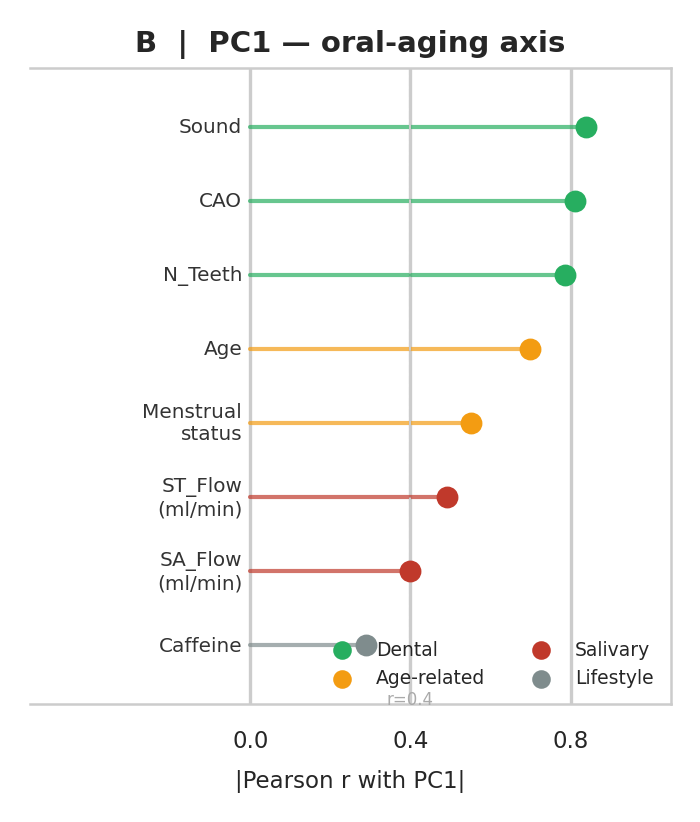

Control-enriched (higher mean in controls): ['Cardiovascular', 'Diabetes', 'Former_cigarettes/day', 'Gastrointestinal', 'Hyposalivation_med', 'SA_Flow (ml/min)', 'Smoking']
Saved figures\fig2_panel_C.pdf / .png


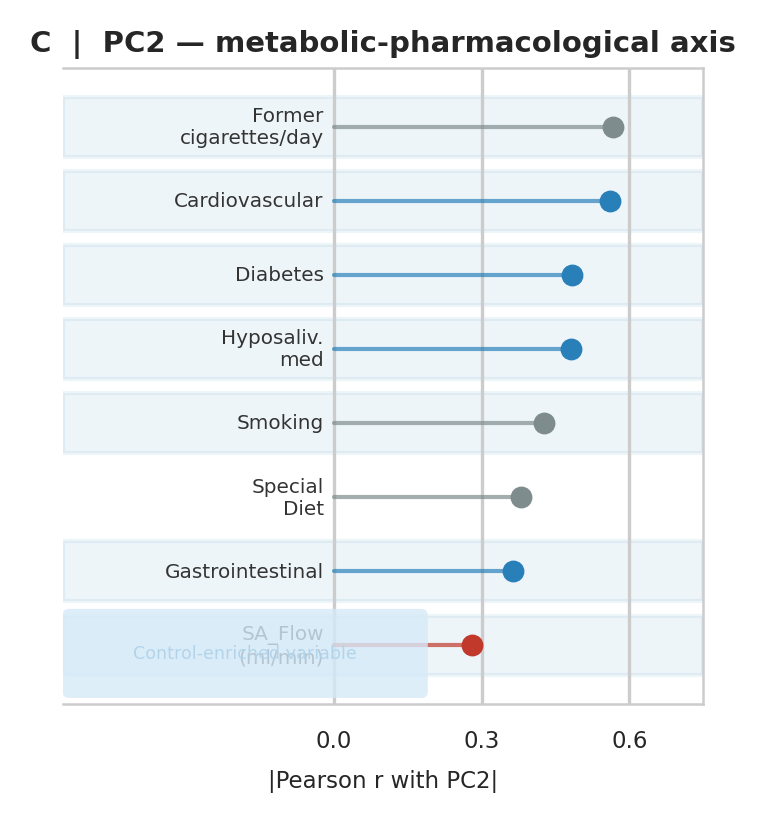

In [25]:
def plot_pc_lollipop(assoc, variables, pc, title, xlim, xticks, filename,
                     highlight=None, ref_line=None, domain_legend=False):
    # Lollipop chart of |r| between selected variables and a principal component.
    scores = assoc.set_index("variable").loc[variables, "score"].sort_values()
    highlight = highlight or set()

    with publication_style():
        fig, ax = plt.subplots(figsize=(70 * MM, 70 * MM), dpi=300)
        fig.patch.set_facecolor("white")

        for i, (var, score) in enumerate(scores.items()):
            color = DOMAIN_COLORS[VARIABLE_DOMAINS[var]]
            if var in highlight:
                ax.axhspan(i - 0.4, i + 0.4, alpha=0.08, color=COLORS["control"], zorder=0)
            ax.plot([0, score], [i, i], color=color, lw=1.0, alpha=0.7)
            ax.scatter(score, i, s=18, color=color, zorder=5)
            ax.text(-0.02, i, DISPLAY_LABELS.get(var, var), ha="right", va="center",
                    fontsize=4.8, color="#333333")

        if ref_line is not None:
            ax.axvline(ref_line, color="#cccccc", lw=0.5, ls="--")
            ax.text(ref_line, -0.8, f"r={ref_line}", ha="center", fontsize=4, color="#aaaaaa")

        ax.set_xlim(*xlim)
        ax.set_ylim(-0.8, len(scores) - 0.2)
        ax.set_xticks(xticks)
        ax.set_yticks([])
        ax.set_xlabel(f"|Pearson r with {pc}|", fontsize=5.5)
        ax.set_title(title, pad=4, fontweight="bold")
        ax.spines["left"].set_visible(False)

        if domain_legend:
            for label, domain in [("Dental", "dental"), ("Age-related", "age"),
                                  ("Salivary", "saliva"), ("Lifestyle", "lifestyle")]:
                ax.scatter([], [], color=DOMAIN_COLORS[domain], s=12, label=label)
            ax.legend(fontsize=4.5, loc="lower right", ncol=2)
        if highlight:
            ax.add_patch(mpatches.FancyBboxPatch(
                (0.01, 0.02), 0.55, 0.12, boxstyle="round,pad=0.01", transform=ax.transAxes,
                facecolor="#D6EAF8", edgecolor="none", alpha=0.8, zorder=5))
            ax.text(0.285, 0.08, "Control-enriched variable", transform=ax.transAxes,
                    ha="center", va="center", fontsize=4.2, color=COLORS["control"])

        save_figure(fig, filename)
        plt.show()


# Panel B — PC1 (oral-ageing axis)
FIG2_PC1_VARS = ["Sound", "CAO", "N_Teeth", "Age", "Menstrual_status", ST_FLOW, SA_FLOW, "Caffeine"]
plot_pc_lollipop(pc1_assoc, FIG2_PC1_VARS, "PC1", "B  |  PC1 — oral-aging axis",
                 xlim=(-0.55, 1.05), xticks=[0, 0.4, 0.8], filename="fig2_panel_B",
                 ref_line=0.4, domain_legend=True)

# Panel C — PC2 (metabolic-pharmacological axis)
FIG2_PC2_VARS = ["Former_cigarettes/day", "Cardiovascular", "Diabetes", "Hyposalivation_med",
                 "Smoking", "Special_Diet", "Gastrointestinal", SA_FLOW]
group_means = data.groupby(TARGET)[FIG2_PC2_VARS].mean()
control_enriched = {v for v in FIG2_PC2_VARS if group_means.loc[0, v] > group_means.loc[1, v]}
print(f"Control-enriched (higher mean in controls): {sorted(control_enriched)}")

plot_pc_lollipop(pc2_assoc, FIG2_PC2_VARS, "PC2", "C  |  PC2 — metabolic-pharmacological axis",
                 xlim=(-0.55, 0.75), xticks=[0, 0.3, 0.6], filename="fig2_panel_C",
                 highlight=control_enriched)

**Panel D — bootstrap stability of PCA loadings.** Rows are resampled with replacement, re-standardised and refitted
(PCA, 2 components). Each bootstrap component is sign-aligned to the reference solution, since eigenvectors are only
defined up to ±1. A variable is considered stable when its dominant loading is at least 2.5 times its bootstrap
standard deviation.

,PC1_loading,PC2_loading,SD_PC1,SD_PC2,euclidean_SD,SNR,stable
Diabetes,-0.027,0.326,0.066,0.100,0.120,3.265,True
Age,-0.363,0.099,0.020,0.092,0.094,17.923,True
Cardiovascular,-0.050,0.378,0.062,0.090,0.110,4.180,True
CAO,-0.423,-0.096,0.020,0.102,0.104,20.982,True
ST_Flow (ml/min),0.255,-0.120,0.039,0.144,0.150,6.510,True
SA_Flow (ml/min),0.208,-0.189,0.041,0.130,0.136,5.093,True
IPC,-0.130,0.146,0.044,0.106,0.115,1.378,False
N_Oral_mucosa disorder,-0.117,0.020,0.060,0.101,0.117,1.952,False


Saved figures\fig2_panel_D.pdf / .png


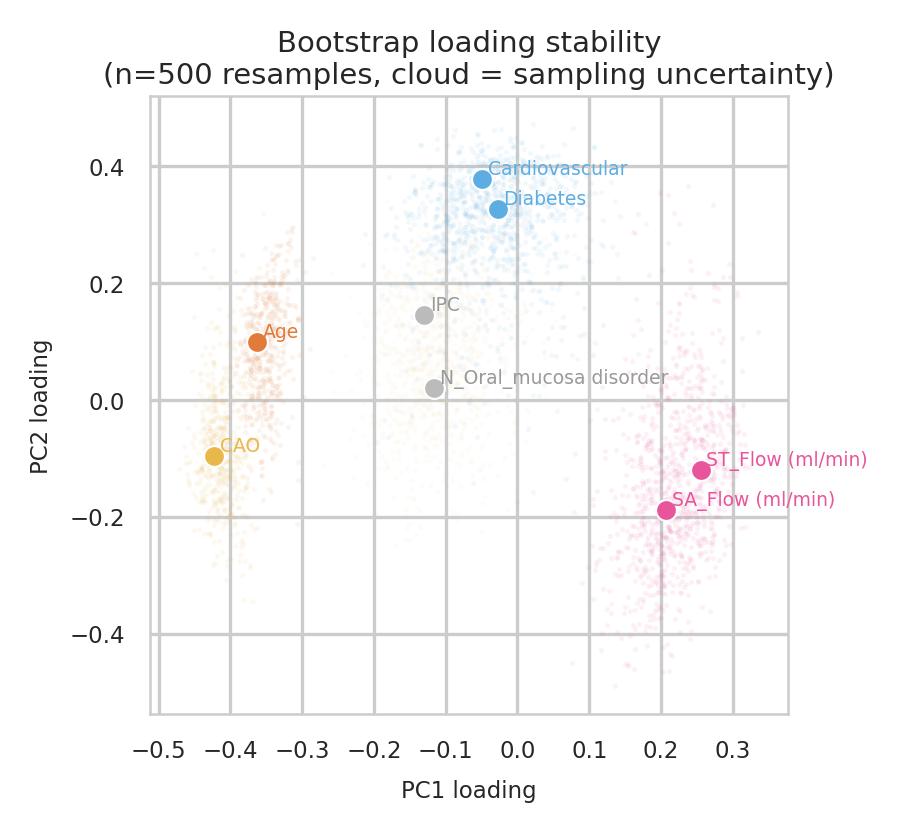

In [26]:
BOOT_COLORS = dict(dental="#E8B84B", demographic="#E07B39", salivary="#E8559A",
                   lifestyle="#8E6BBF", comorbidity="#5DADE2")
BOOT_VARS = {
    "Diabetes": "comorbidity", "Age": "demographic", "Cardiovascular": "comorbidity",
    "CAO": "dental", ST_FLOW: "salivary", SA_FLOW: "salivary",
    "IPC": "dental", "N_Oral_mucosa disorder": "dental",
}
SNR_THRESHOLD = 2.5

X_raw = pca_features[numeric_cols].astype(float).values
boot_vars = [v for v in BOOT_VARS if v in numeric_cols]
boot_idx = [numeric_cols.index(v) for v in boot_vars]
ref_components = pca.components_

rng = np.random.default_rng(RANDOM_STATE)
boot_loadings = np.zeros((N_BOOTSTRAP, 2, len(boot_vars)))
for b in range(N_BOOTSTRAP):
    sample = rng.integers(0, len(X_raw), size=len(X_raw))
    components = PCA(n_components=2).fit(StandardScaler().fit_transform(X_raw[sample])).components_.copy()
    for k in range(2):
        if np.dot(components[k], ref_components[k]) < 0:
            components[k] *= -1
    boot_loadings[b] = components[:, boot_idx]

ref_l1, ref_l2 = ref_components[0, boot_idx], ref_components[1, boot_idx]
sd_l1, sd_l2 = boot_loadings[:, 0, :].std(axis=0), boot_loadings[:, 1, :].std(axis=0)
pc1_dominant = np.abs(ref_l1) >= np.abs(ref_l2)
snr = np.maximum(np.abs(ref_l1), np.abs(ref_l2)) / (np.where(pc1_dominant, sd_l1, sd_l2) + 1e-9)

bootstrap_summary = pd.DataFrame({
    "PC1_loading": ref_l1, "PC2_loading": ref_l2, "SD_PC1": sd_l1, "SD_PC2": sd_l2,
    "euclidean_SD": np.sqrt(sd_l1 ** 2 + sd_l2 ** 2), "SNR": snr, "stable": snr >= SNR_THRESHOLD,
}, index=boot_vars)
display(bootstrap_summary.round(3))

with publication_style():
    fig, ax = plt.subplots(figsize=(75 * MM, 70 * MM), dpi=300)
    fig.patch.set_facecolor("white")
    for i, var in enumerate(boot_vars):
        color = BOOT_COLORS[BOOT_VARS[var]]
        stable = bootstrap_summary.loc[var, "stable"]
        ax.scatter(boot_loadings[:, 0, i], boot_loadings[:, 1, i], s=1.5, c=color,
                   alpha=0.08 if stable else 0.03, zorder=2, lw=0)
        ax.scatter(ref_l1[i], ref_l2[i], s=25, c=color if stable else "#bbbbbb",
                   zorder=5, edgecolors="white", linewidths=0.5)
        ax.text(ref_l1[i] + 0.008, ref_l2[i] + 0.008, var, fontsize=4.5,
                color=color if stable else "#999999", zorder=6)

    ax.axhline(0, color="#cccccc", lw=0.4, zorder=0)
    ax.axvline(0, color="#cccccc", lw=0.4, zorder=0)
    ax.set_xlabel("PC1 loading", fontsize=5.5)
    ax.set_ylabel("PC2 loading", fontsize=5.5)
    ax.set_title(f"Bootstrap loading stability\n(n={N_BOOTSTRAP} resamples, cloud = sampling uncertainty)", pad=3)
    fig.tight_layout()
    save_figure(fig, "fig2_panel_D")
    plt.show()

### Figure 3 — Full Random Forest model: performance and interpretability

(A) ROC curve with Youden-optimal threshold; (B) SHAP beeswarm for the SjS class; (C) impurity-based feature
importances; (D) first tree of the ensemble (depth ≤ 3); (E) confusion matrix on the held-out test set.

In [27]:
def draw_shap_beeswarm(ax, shap_values, X_test, rng, point_size=8, alpha=0.7):
    # SHAP beeswarm; colour = min-max normalised feature value. Returns the colormap.
    values = shap_values.values
    feature_names = X_test.columns.tolist()
    order = np.argsort(np.abs(values).mean(axis=0))  # ascending → most important on top
    cmap = plt.cm.RdBu_r
    for rank, idx in enumerate(order):
        raw = X_test.iloc[:, idx].values
        normalised = (raw - raw.min()) / (np.ptp(raw) + 1e-9)
        jitter = rng.normal(0, 0.12, len(values))
        ax.scatter(values[:, idx], rank + jitter, c=normalised, cmap=cmap,
                   s=point_size, alpha=alpha, lw=0, vmin=0, vmax=1, zorder=3)
        ax.scatter(values[:, idx].mean(), rank, c="black", s=20, zorder=6, marker="|")
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels([feature_names[i] for i in order])
    return cmap


def draw_confusion_matrix(ax, cm, cmap, bold_ticks=False):
    ax.imshow(cm, interpolation="nearest", cmap=cmap, aspect="auto")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    tick_kw = dict(fontsize=6, fontweight="bold" if bold_ticks else "normal")
    ax.set_xticklabels(["Control", "SjS"], **tick_kw)
    ax.set_yticklabels(["Control", "SjS"], **tick_kw)
    tags = {(0, 0): "TN", (0, 1): "FP", (1, 0): "FN", (1, 1): "TP"}
    threshold = cm.max() / 2
    for (i, j), value in np.ndenumerate(cm):
        dark = value > threshold
        ax.text(j, i, str(value), ha="center", va="center", fontsize=14, fontweight="bold",
                color="white" if dark else "#333333")
        ax.text(j, i + 0.32, tags[(i, j)], ha="center", va="center", fontsize=5.5, style="italic",
                fontweight="bold", color="white" if dark else "#333333")


def youden_point(fpr, tpr):
    j = np.argmax(tpr - fpr)
    return fpr[j], tpr[j]

Saved figures\fig3.pdf / .png


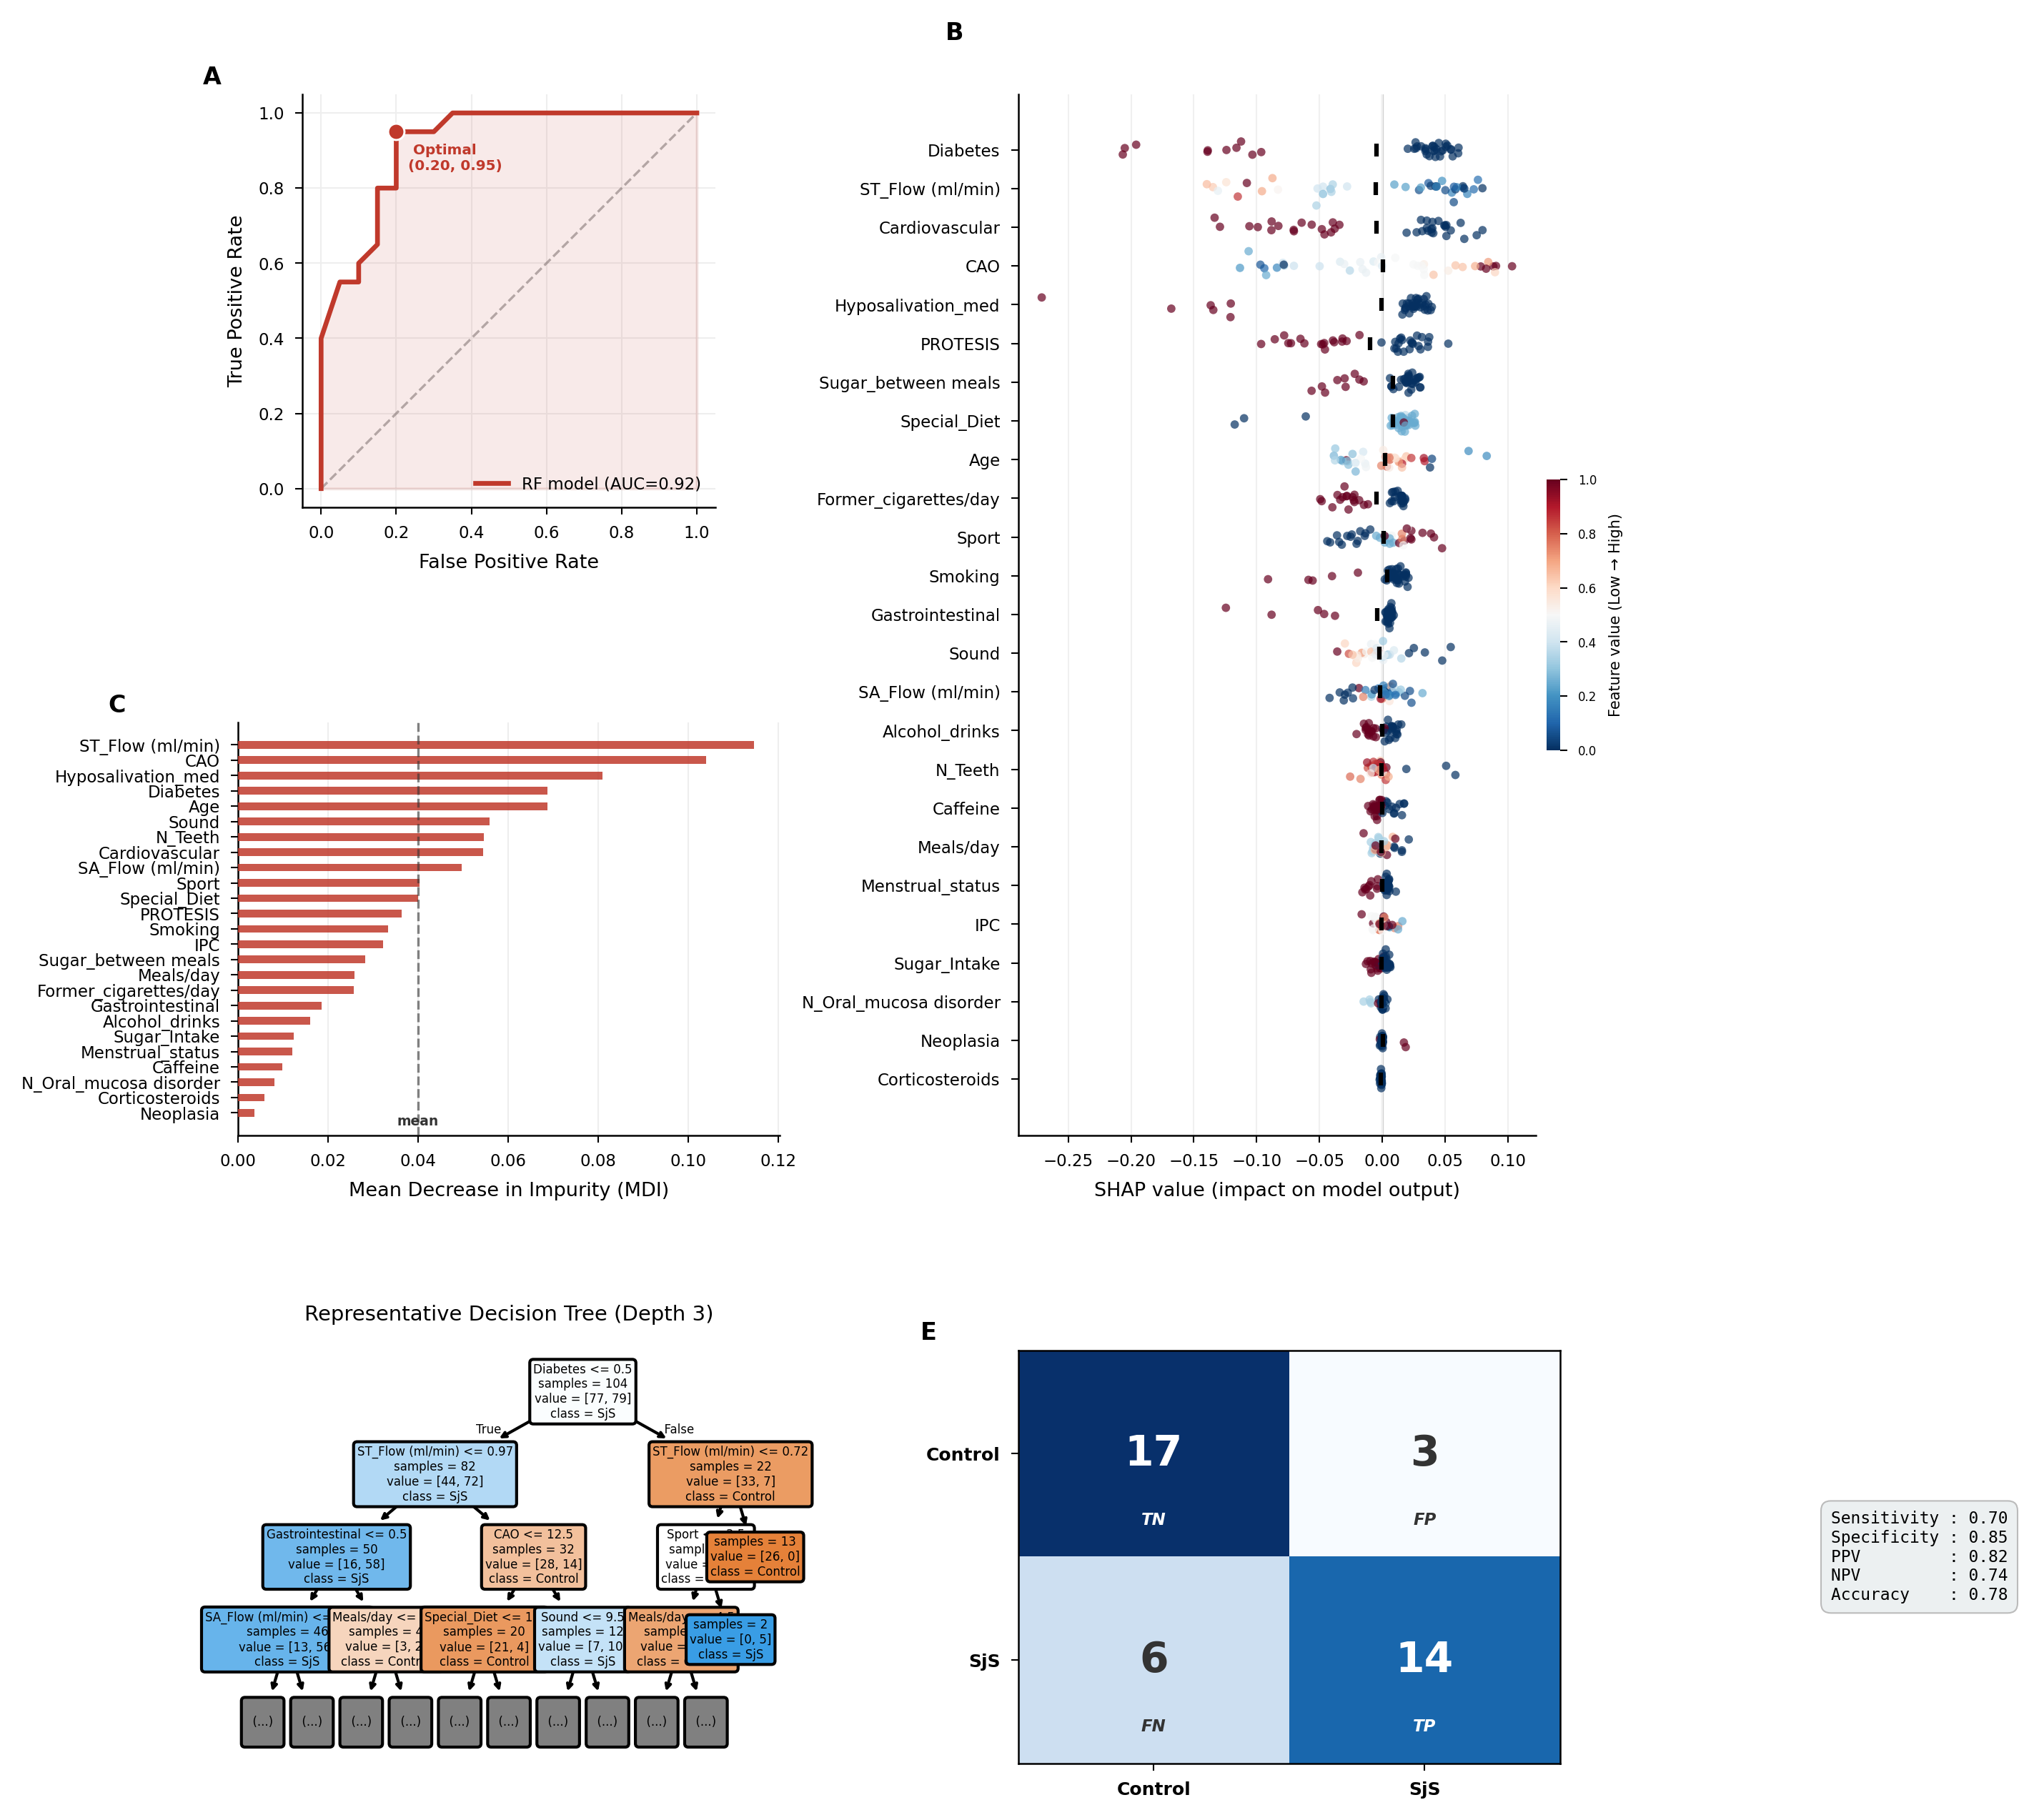

In [28]:
res = rf_full
m = classification_metrics(res.y_test, res.y_pred)
mdi = pd.Series(res.model.feature_importances_, index=res.X_train.columns).sort_values()

with publication_style(grid=False):
    fig = plt.figure(figsize=(180 * MM, 230 * MM), dpi=300)
    fig.patch.set_facecolor("white")
    gs = gridspec.GridSpec(3, 2, figure=fig, left=0.10, right=0.97, top=0.93, bottom=0.07,
                           wspace=0.44, hspace=0.52)
    ax_roc, ax_bee = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0:2, 1])
    ax_mdi, ax_tree, ax_cm = fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[2, 0]), fig.add_subplot(gs[2, 1])

    # A — ROC curve
    panel_label(ax_roc, "A", dx=-0.24)
    ax_roc.grid(True, color="#EEEEEE", linestyle="-", linewidth=0.5, zorder=0)
    ax_roc.plot(res.fpr, res.tpr, color=COLORS["sjogren"], lw=1.6,
                label=f"RF model (AUC={res.roc_auc:.2f})", zorder=4)
    ax_roc.fill_between(res.fpr, res.tpr, alpha=0.1, color=COLORS["sjogren"], zorder=3)
    ax_roc.plot([0, 1], [0, 1], color="#666666", lw=0.8, ls="--", alpha=0.5, zorder=2)
    x_opt, y_opt = youden_point(res.fpr, res.tpr)
    ax_roc.scatter(x_opt, y_opt, s=30, color=COLORS["sjogren"], zorder=6, edgecolors="white", lw=0.7)
    ax_roc.annotate(f" Optimal\n({x_opt:.2f}, {y_opt:.2f})", xy=(x_opt, y_opt), fontsize=4.8,
                    color=COLORS["sjogren"], va="top", xytext=(4, -4), textcoords="offset points",
                    fontweight="bold")
    ax_roc.set_xlabel("False Positive Rate")
    ax_roc.set_ylabel("True Positive Rate")
    hide_top_right_spines(ax_roc)
    ax_roc.set_aspect("equal")
    ax_roc.legend(loc="lower right")

    # B — SHAP beeswarm
    panel_label(ax_bee, "B", dx=-0.14)
    ax_bee.grid(True, axis="x", color="#F0F0F0", linestyle="-", linewidth=0.5, zorder=0)
    cmap = draw_shap_beeswarm(ax_bee, res.shap_values, res.X_test, np.random.default_rng(RANDOM_STATE))
    ax_bee.tick_params(axis="y", labelsize=5.5)
    ax_bee.axvline(0, color="#666666", lw=0.8, alpha=0.3, zorder=1)
    ax_bee.set_xlabel("SHAP value (impact on model output)")
    hide_top_right_spines(ax_bee)
    cb = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap), ax=ax_bee, fraction=0.025, pad=0.02)
    cb.set_label("Feature value (Low → High)", fontsize=5)
    cb.ax.tick_params(labelsize=4)
    cb.outline.set_visible(False)

    # C — MDI feature importance
    panel_label(ax_mdi, "C", dx=-0.24)
    ax_mdi.grid(True, axis="x", color="#EEEEEE", linestyle="-", linewidth=0.5, zorder=0)
    ax_mdi.barh(range(len(mdi)), mdi.values, color=COLORS["sjogren"], alpha=0.85, height=0.5, zorder=3)
    ax_mdi.set_yticks(range(len(mdi)))
    ax_mdi.set_yticklabels(mdi.index, fontsize=5.5)
    ax_mdi.set_xlabel("Mean Decrease in Impurity (MDI)")
    hide_top_right_spines(ax_mdi)
    ax_mdi.axvline(mdi.mean(), color="#333333", lw=0.8, ls="--", alpha=0.6, zorder=4)
    ax_mdi.text(mdi.mean(), -0.8, "mean", color="#333333", fontsize=4.5, ha="center", fontweight="bold")

    # D — representative tree
    panel_label(ax_tree, "D", dx=-0.07)
    plot_tree(res.model.estimators_[0], feature_names=res.X_train.columns.tolist(),
              class_names=["Control", "SjS"], filled=True, rounded=True, fontsize=4,
              max_depth=3, ax=ax_tree, impurity=False)
    ax_tree.set_title("Representative Decision Tree (Depth 3)", pad=10, fontsize=7)

    # E — confusion matrix
    panel_label(ax_cm, "E", dx=-0.18)
    draw_confusion_matrix(ax_cm, m["cm"], plt.cm.Blues, bold_ticks=True)
    ax_cm.text(1.5, 0.5, metrics_text(m), transform=ax_cm.transAxes, fontsize=5.5, va="center",
               fontfamily="monospace",
               bbox=dict(boxstyle="round,pad=0.6", facecolor=COLORS["light"], edgecolor="#BBBBBB", lw=0.5))

    save_figure(fig, "fig3")
    plt.show()

### Figure 4 — Biological model vs full model

(A) ROC comparison; (B) SHAP beeswarm of the biological model; (C) MDI importances of both models;
(D) accuracy of the biological model by age group (5-fold CV); (E) confusion matrix of the biological model.

Saved figures\fig4.pdf / .png


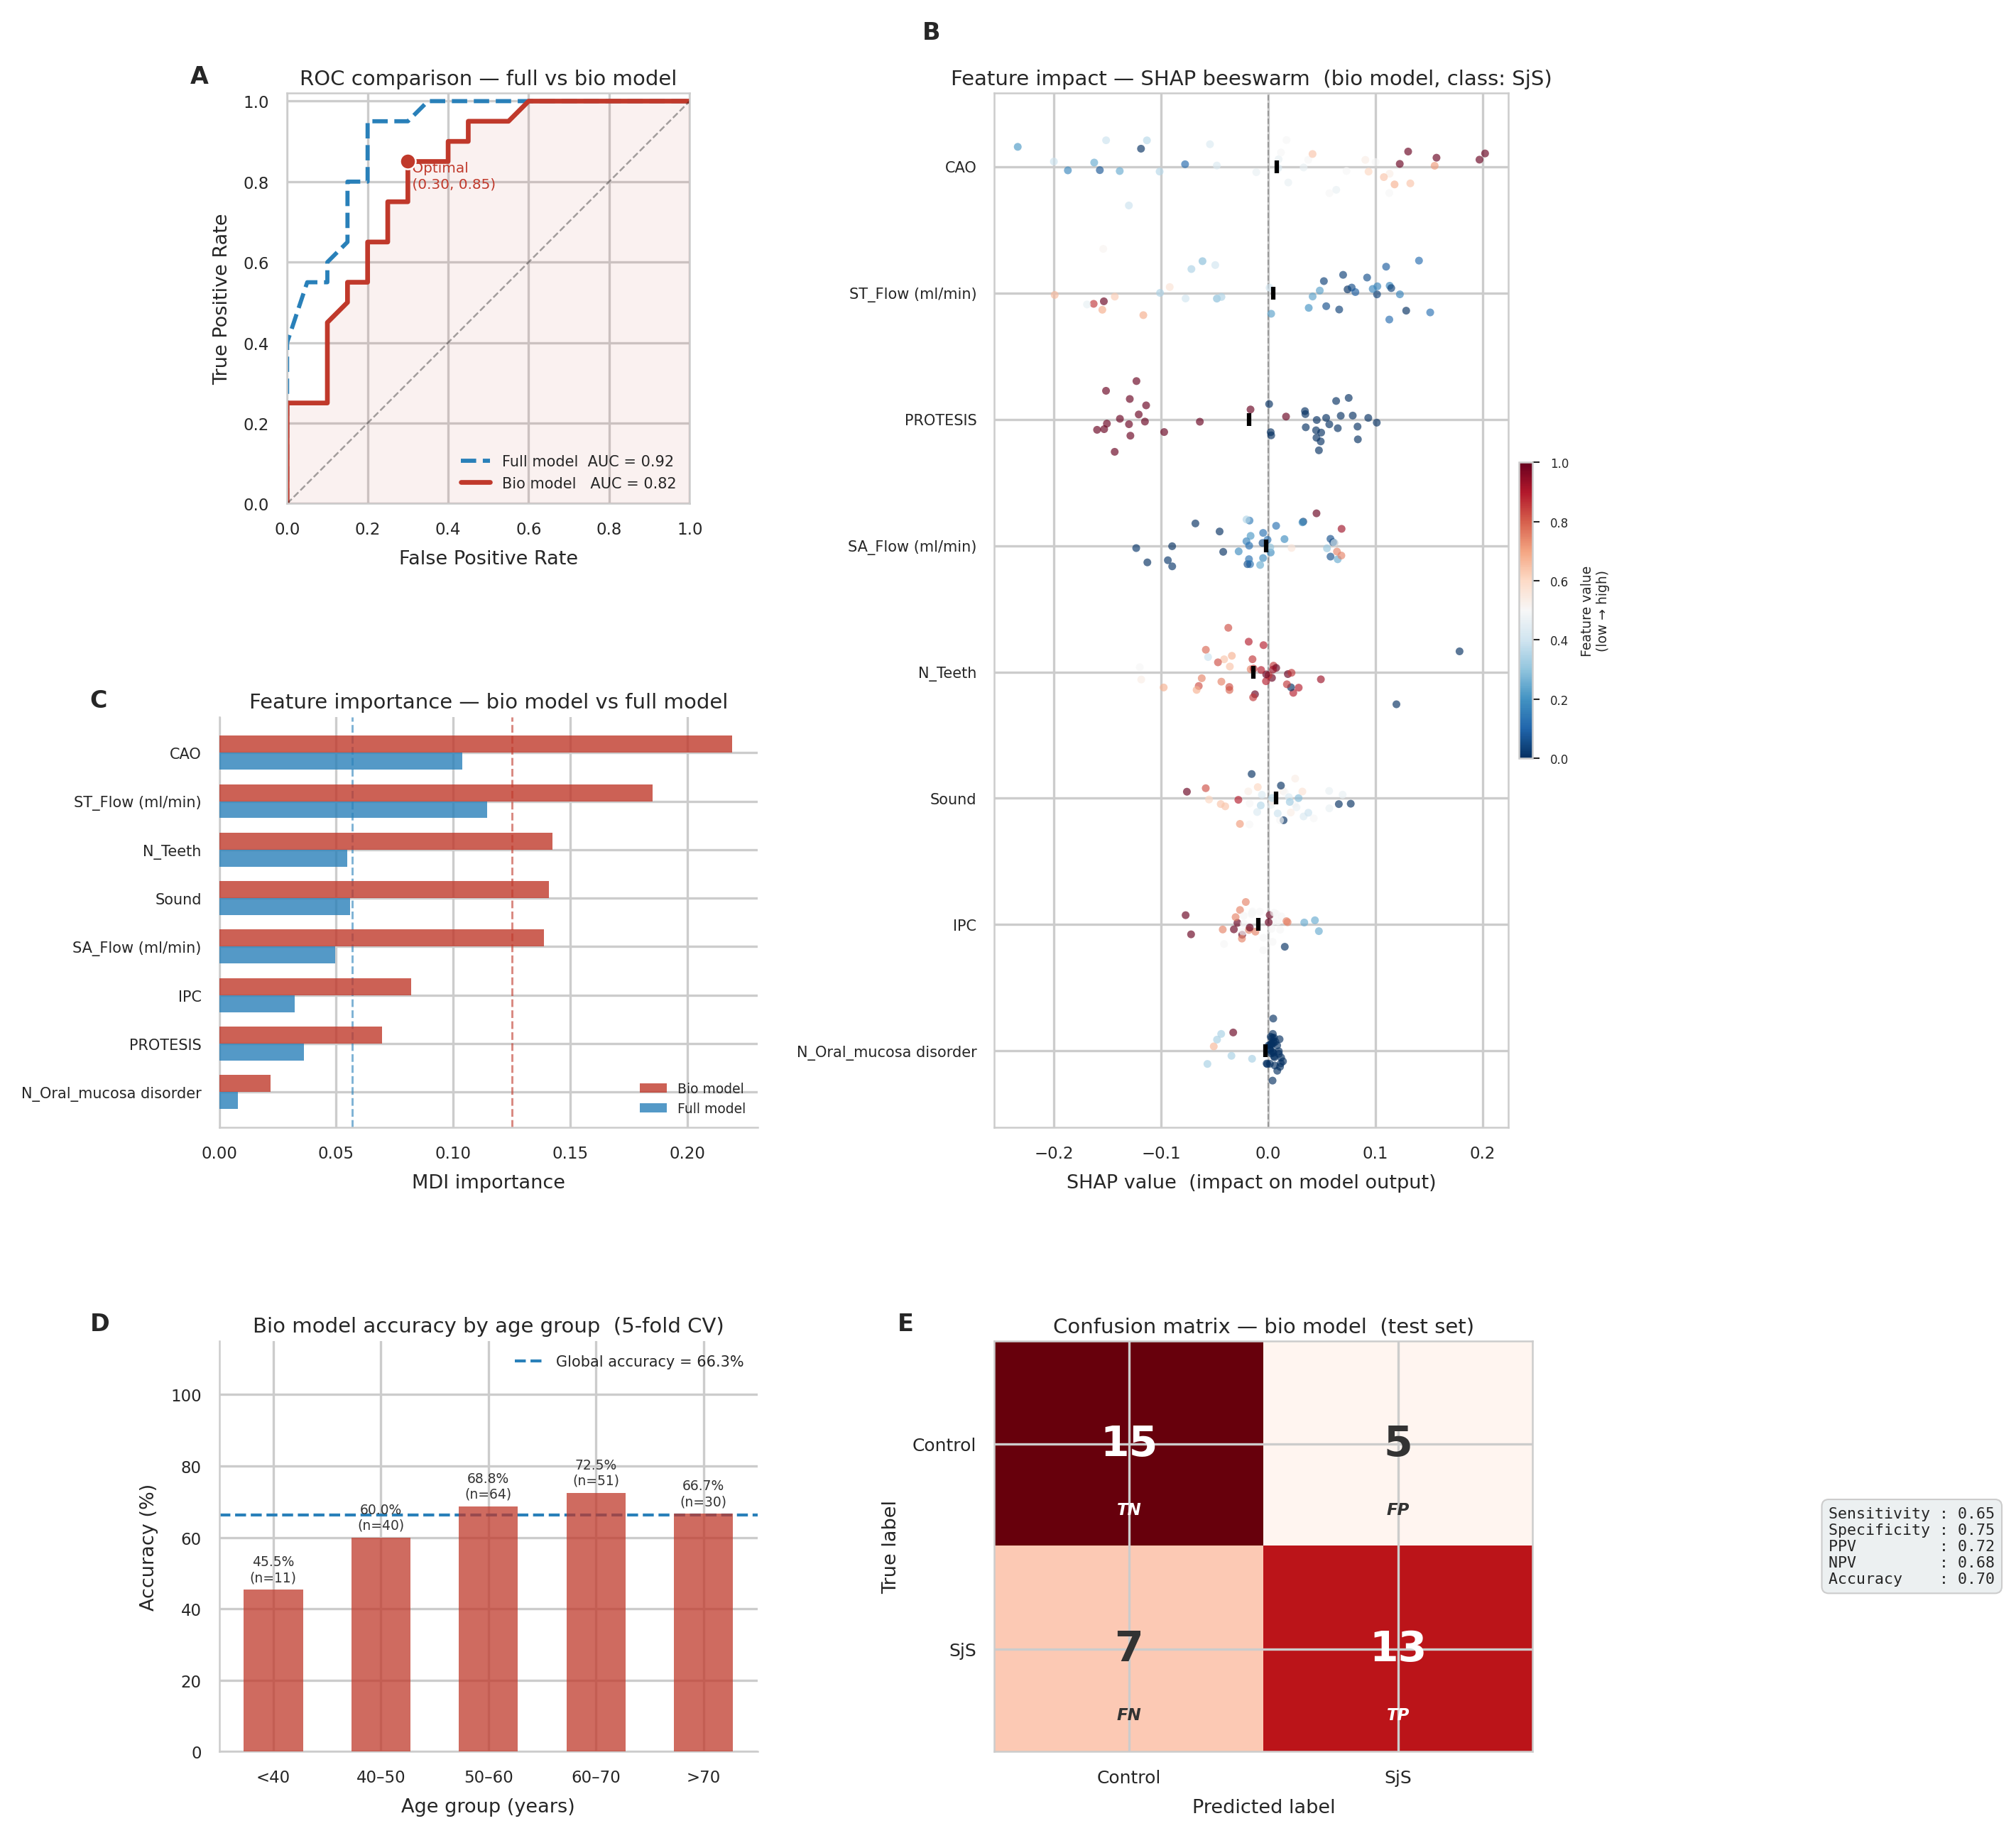

In [29]:
m_bio = classification_metrics(rf_bio.y_test, rf_bio.y_pred)
mdi_full = pd.Series(rf_full.model.feature_importances_, index=rf_full.X_train.columns)
mdi_bio = pd.Series(rf_bio.model.feature_importances_, index=rf_bio.X_train.columns)

with publication_style():
    fig = plt.figure(figsize=(180 * MM, 230 * MM), dpi=300)
    fig.patch.set_facecolor("white")
    gs = gridspec.GridSpec(3, 2, figure=fig, left=0.10, right=0.97, top=0.93, bottom=0.07,
                           wspace=0.44, hspace=0.52)
    ax_roc, ax_bee = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0:2, 1])
    ax_mdi, ax_age, ax_cm = fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[2, 0]), fig.add_subplot(gs[2, 1])

    # A — ROC comparison
    panel_label(ax_roc, "A", dx=-0.24)
    ax_roc.plot(rf_full.fpr, rf_full.tpr, color=COLORS["control"], lw=1.4, ls="--",
                label=f"Full model  AUC = {rf_full.roc_auc:.2f}")
    ax_roc.plot(rf_bio.fpr, rf_bio.tpr, color=COLORS["sjogren"], lw=1.6,
                label=f"Bio model   AUC = {rf_bio.roc_auc:.2f}")
    ax_roc.fill_between(rf_bio.fpr, rf_bio.tpr, alpha=0.07, color=COLORS["sjogren"])
    ax_roc.plot([0, 1], [0, 1], "k--", lw=0.6, alpha=0.35)
    x_opt, y_opt = youden_point(rf_bio.fpr, rf_bio.tpr)
    ax_roc.scatter(x_opt, y_opt, s=28, color=COLORS["sjogren"], zorder=6, edgecolors="white", lw=0.6)
    ax_roc.annotate(f" Optimal\n ({x_opt:.2f}, {y_opt:.2f})", xy=(x_opt, y_opt),
                    fontsize=4.8, color=COLORS["sjogren"], va="top")
    ax_roc.set_xlabel("False Positive Rate")
    ax_roc.set_ylabel("True Positive Rate")
    ax_roc.set_title("ROC comparison — full vs bio model", pad=3)
    ax_roc.legend(fontsize=5.0, loc="lower right")
    ax_roc.set_xlim(0, 1)
    ax_roc.set_ylim(0, 1.02)
    ax_roc.set_aspect("equal")

    # B — SHAP beeswarm (biological model)
    panel_label(ax_bee, "B", dx=-0.14)
    cmap = draw_shap_beeswarm(ax_bee, rf_bio.shap_values, rf_bio.X_test,
                              np.random.default_rng(RANDOM_STATE), point_size=7, alpha=0.65)
    ax_bee.tick_params(axis="y", labelsize=5)
    ax_bee.axvline(0, color="#999999", lw=0.5, ls="--")
    ax_bee.set_xlabel("SHAP value  (impact on model output)")
    ax_bee.set_title("Feature impact — SHAP beeswarm  (bio model, class: SjS)", pad=3)
    scalar_map = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
    cb = fig.colorbar(scalar_map, ax=ax_bee, fraction=0.025, pad=0.02, aspect=22)
    cb.set_label("Feature value\n(low → high)", fontsize=4.5)
    cb.ax.tick_params(labelsize=4)

    # C — MDI comparison on the biological-model features
    panel_label(ax_mdi, "C", dx=-0.24)
    features = mdi_bio.sort_values().index
    bio_vals, full_vals = mdi_bio.reindex(features).fillna(0), mdi_full.reindex(features).fillna(0)
    y_pos, height = np.arange(len(features)), 0.35
    ax_mdi.barh(y_pos + height / 2, bio_vals, height=height, color=COLORS["sjogren"], alpha=0.80,
                edgecolor="none", zorder=3, label="Bio model")
    ax_mdi.barh(y_pos - height / 2, full_vals, height=height, color=COLORS["control"], alpha=0.80,
                edgecolor="none", zorder=3, label="Full model")
    ax_mdi.set_yticks(y_pos)
    ax_mdi.set_yticklabels(features, fontsize=5)
    ax_mdi.set_xlabel("MDI importance")
    ax_mdi.set_title("Feature importance — bio model vs full model", pad=3)
    ax_mdi.axvline(bio_vals.mean(), color=COLORS["sjogren"], lw=0.7, ls="--", alpha=0.6)
    ax_mdi.axvline(full_vals.mean(), color=COLORS["control"], lw=0.7, ls="--", alpha=0.6)
    ax_mdi.legend(fontsize=4.5, loc="lower right")
    hide_top_right_spines(ax_mdi)

    # D — accuracy by age group
    panel_label(ax_age, "D", dx=-0.24)
    x_pos = np.arange(len(accuracy_by_age))
    bars = ax_age.bar(x_pos, accuracy_by_age["accuracy"] * 100, color=COLORS["sjogren"], alpha=0.75,
                      edgecolor="none", width=0.55, zorder=3)
    ax_age.axhline(overall_cv_accuracy * 100, color=COLORS["control"], lw=1.0, ls="--",
                   label=f"Global accuracy = {overall_cv_accuracy * 100:.1f}%")
    ax_age.set_xticks(x_pos)
    ax_age.set_xticklabels(accuracy_by_age["age_group"].astype(str), fontsize=5.5)
    ax_age.set_xlabel("Age group (years)")
    ax_age.set_ylabel("Accuracy (%)")
    ax_age.set_ylim(0, 115)
    ax_age.set_title("Bio model accuracy by age group  (5-fold CV)", pad=3)
    ax_age.legend(fontsize=5.0)
    for bar, (_, row) in zip(bars, accuracy_by_age.iterrows()):
        ax_age.text(bar.get_x() + bar.get_width() / 2, row["accuracy"] * 100 + 1.5,
                    f"{row['accuracy'] * 100:.1f}%\n(n={int(row['n'])})",
                    ha="center", va="bottom", fontsize=4.5, color="#333333")
    hide_top_right_spines(ax_age)

    # E — confusion matrix (biological model)
    panel_label(ax_cm, "E", dx=-0.18)
    draw_confusion_matrix(ax_cm, m_bio["cm"], plt.cm.Reds)
    ax_cm.set_xlabel("Predicted label", fontsize=6.5)
    ax_cm.set_ylabel("True label", fontsize=6.5)
    ax_cm.set_title("Confusion matrix — bio model  (test set)", pad=3)
    ax_cm.text(1.55, 0.5, metrics_text(m_bio), transform=ax_cm.transAxes, fontsize=5.2, va="center",
               ha="left", fontfamily="monospace",
               bbox=dict(boxstyle="round,pad=0.45", facecolor=COLORS["light"], edgecolor="#cccccc",
                         linewidth=0.5))

    save_figure(fig, "fig4")
    plt.show()

### Figure 5 — Salivary flow: hormonal, temporal and multivariable determinants

(A) Pre- vs post-menopause within the 45–55 window; (B) years since last menstruation vs flow; (C) age trajectories;
(D) flow by age stratum; (E) adjusted OLS effects (95% CI).

Saved figures\fig5.pdf / .png


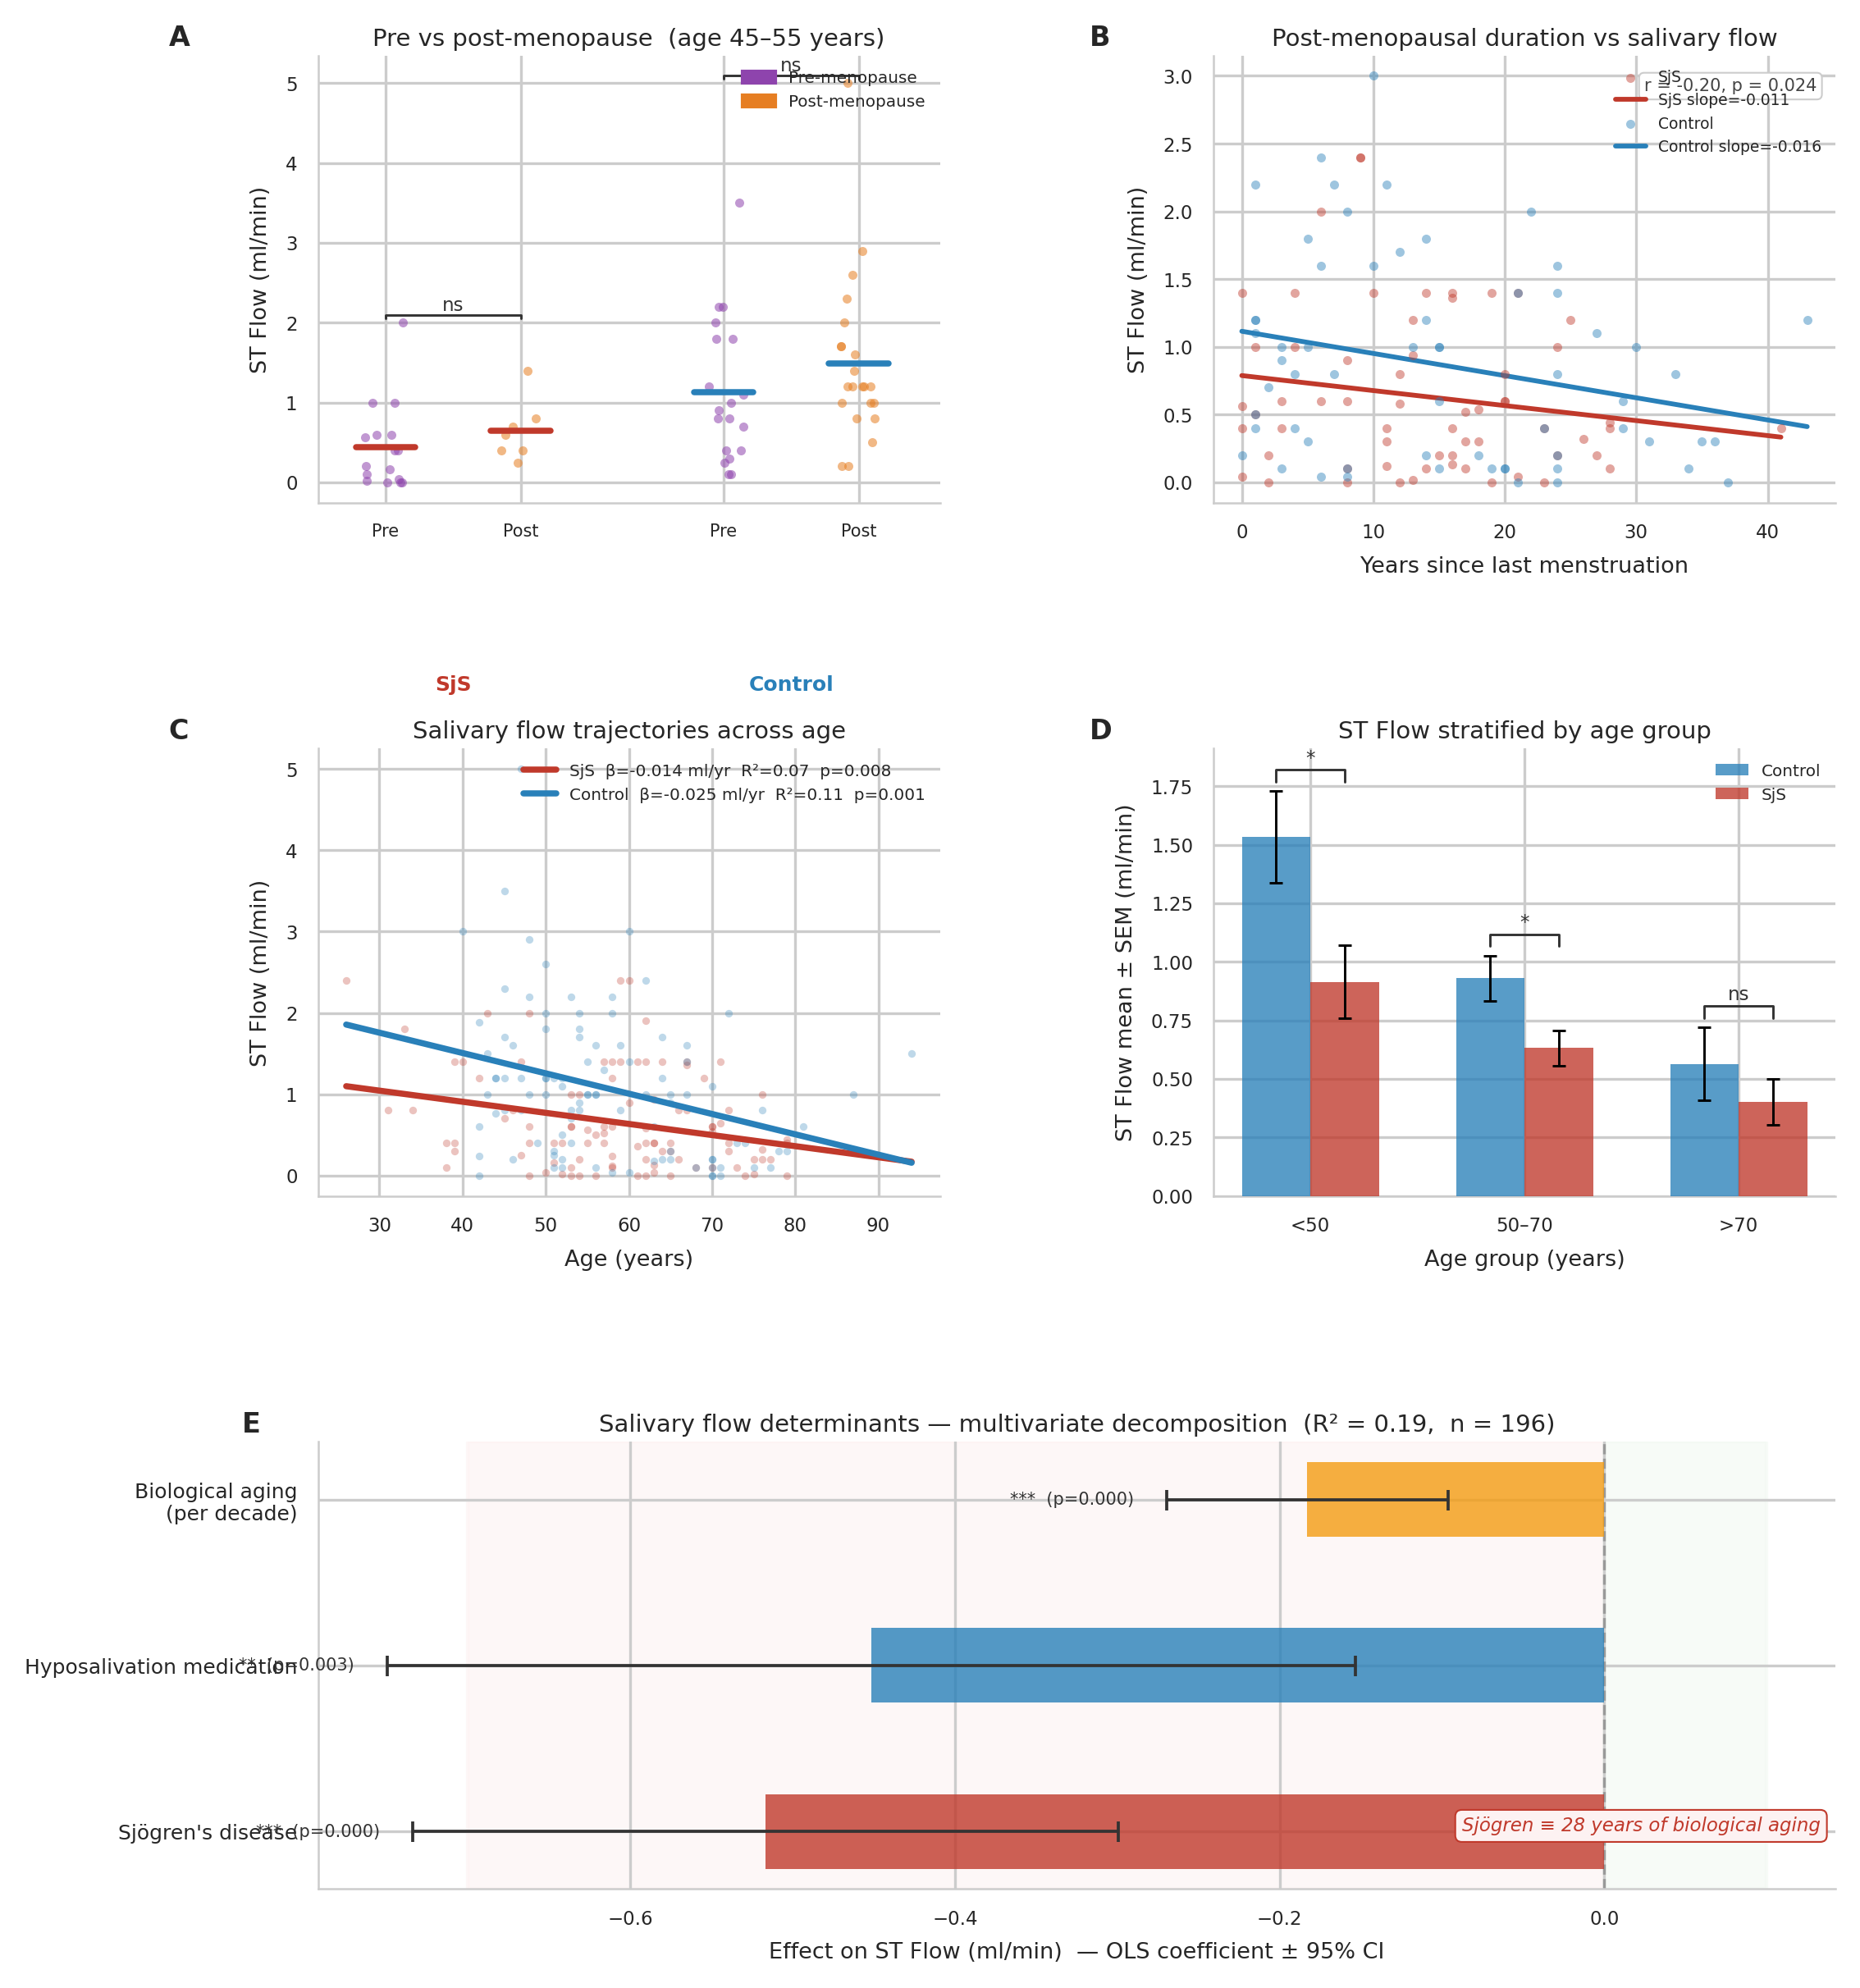

In [30]:
with publication_style():
    fig = plt.figure(figsize=(180 * MM, 220 * MM), dpi=300)
    fig.patch.set_facecolor("white")
    gs = gridspec.GridSpec(3, 2, figure=fig, left=0.10, right=0.97, top=0.93, bottom=0.07,
                           wspace=0.44, hspace=0.55)
    ax_a, ax_b = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])
    ax_c, ax_d = fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])
    ax_e = fig.add_subplot(gs[2, :])

    # A — pre vs post menopause
    panel_label(ax_a, "A", dx=-0.24)
    jitter_rng = np.random.default_rng(0)
    x_positions = {"SjS": {"pre": 0.5, "post": 1.5}, "Control": {"pre": 3.0, "post": 4.0}}
    group_colors = {"SjS": COLORS["sjogren"], "Control": COLORS["control"]}
    xticks, xlabels = [], []
    for group in ["SjS", "Control"]:
        for status in ["pre", "post"]:
            xc = x_positions[group][status]
            values = menopause_flow[group][status].values
            ax_a.scatter(xc + jitter_rng.uniform(-0.15, 0.15, len(values)), values, s=7,
                         color=COLORS[status], alpha=0.55, zorder=4, lw=0)
            ax_a.plot([xc - 0.22, xc + 0.22], [values.mean()] * 2, color=group_colors[group], lw=1.8, zorder=5)
            xticks.append(xc)
            xlabels.append(status.capitalize())
        ymax = max(menopause_flow[group]["pre"].max(), menopause_flow[group]["post"].max())
        add_significance_bar(ax_a, x_positions[group]["pre"], x_positions[group]["post"],
                             ymax + 0.05, menopause_flow[group]["p"])
    for x_text, group in [(1.0, "SjS"), (3.5, "Control")]:
        ax_a.text(x_text, -0.42, group, ha="center", fontsize=6, color=group_colors[group],
                  fontweight="bold", transform=ax_a.get_xaxis_transform())
    ax_a.set_xticks(xticks)
    ax_a.set_xticklabels(xlabels, fontsize=5)
    ax_a.set_ylabel("ST Flow (ml/min)")
    ax_a.set_title(f"Pre vs post-menopause  (age {MENOPAUSE_WINDOW[0]}–{MENOPAUSE_WINDOW[1]} years)", pad=3)
    ax_a.set_xlim(0, 4.6)
    hide_top_right_spines(ax_a)
    ax_a.legend(handles=[mpatches.Patch(color=COLORS["pre"], label="Pre-menopause"),
                         mpatches.Patch(color=COLORS["post"], label="Post-menopause")],
                fontsize=4.8, loc="upper right")

    # B — years since menopause
    panel_label(ax_b, "B", dx=-0.20)
    for group, color, label in [(1, COLORS["sjogren"], "SjS"), (0, COLORS["control"], "Control")]:
        subset = postmenopausal[postmenopausal[TARGET] == group]
        if len(subset) < 3:
            continue
        ax_b.scatter(subset["years_since_menopause"], subset[ST_FLOW], s=7, color=color,
                     alpha=0.45, lw=0, zorder=3, label=label)
        fit = linregress(subset["years_since_menopause"], subset[ST_FLOW])
        xs = np.linspace(subset["years_since_menopause"].min(), subset["years_since_menopause"].max(), 100)
        ax_b.plot(xs, fit.slope * xs + fit.intercept, color=color, lw=1.4,
                  label=f"{label} slope={fit.slope:.3f}")
    ax_b.text(0.97, 0.95, f"r = {r_p:.2f}, p = {p_p:.3f}", transform=ax_b.transAxes, ha="right",
              va="top", fontsize=5, color="#444444",
              bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#cccccc", lw=0.5))
    ax_b.set_xlabel("Years since last menstruation")
    ax_b.set_ylabel("ST Flow (ml/min)")
    ax_b.set_title("Post-menopausal duration vs salivary flow", pad=3)
    ax_b.legend(fontsize=4.5, loc="upper right")
    hide_top_right_spines(ax_b)

    # C — age trajectories
    panel_label(ax_c, "C", dx=-0.24)
    age_range = np.linspace(age_flow["Age"].min(), age_flow["Age"].max(), 200)
    for group, color, label in [(1, COLORS["sjogren"], "SjS"), (0, COLORS["control"], "Control")]:
        subset = age_flow[age_flow[TARGET] == group]
        fit = age_slopes[group]
        ax_c.scatter(subset["Age"], subset[ST_FLOW], s=5, color=color, alpha=0.30, lw=0, zorder=3)
        ax_c.plot(age_range, fit["slope"] * age_range + fit["intercept"], color=color, lw=1.8, zorder=5,
                  label=f"{label}  β={fit['slope']:.3f} ml/yr  R²={fit['r2']:.2f}  p={fit['p_value']:.3f}")
    ax_c.set_xlabel("Age (years)")
    ax_c.set_ylabel("ST Flow (ml/min)")
    ax_c.set_title("Salivary flow trajectories across age", pad=3)
    ax_c.legend(fontsize=4.8, loc="upper right")
    hide_top_right_spines(ax_c)

    # D — stratified comparison
    panel_label(ax_d, "D", dx=-0.20)
    x, width = np.arange(len(STRATA_LABELS)), 0.32
    for offset, key, color, label in [(-width / 2, "ctrl", COLORS["control"], "Control"),
                                      (+width / 2, "sjs", COLORS["sjogren"], "SjS")]:
        ax_d.bar(x + offset, [flow_by_stratum[s][key].mean() for s in STRATA_LABELS], width,
                 yerr=[flow_by_stratum[s][key].sem() for s in STRATA_LABELS], color=color, alpha=0.78,
                 capsize=2, error_kw=dict(lw=0.7, capthick=0.7), label=label, edgecolor="none", zorder=3)
    for i, stratum in enumerate(STRATA_LABELS):
        s = flow_by_stratum[stratum]
        ymax = max(s["ctrl"].mean() + s["ctrl"].sem(), s["sjs"].mean() + s["sjs"].sem())
        add_significance_bar(ax_d, x[i] - width / 2, x[i] + width / 2, ymax + 0.04, s["p"], h=0.05)
    ax_d.set_xticks(x)
    ax_d.set_xticklabels(STRATA_LABELS)
    ax_d.set_xlabel("Age group (years)")
    ax_d.set_ylabel("ST Flow mean ± SEM (ml/min)")
    ax_d.set_title("ST Flow stratified by age group", pad=3)
    ax_d.legend(fontsize=4.8)
    hide_top_right_spines(ax_d)

    # E — adjusted effects (forest plot)
    panel_label(ax_e, "E", dx=-0.05)
    factors = {TARGET: ("Sjögren's disease", COLORS["sjogren"], 1),
               "Hyposalivation_med": ("Hyposalivation medication", COLORS["control"], 1),
               "Age": ("Biological aging\n(per decade)", COLORS["age"], 10)}
    ci = flow_model.conf_int()
    ax_e.axvspan(-0.7, 0, color="#FDF2F2", alpha=0.6, zorder=0)
    ax_e.axvspan(0, 0.1, color="#F2F9F2", alpha=0.6, zorder=0)
    ax_e.axvline(0, color="#999999", lw=0.8, ls="--", zorder=1)
    for i, (var, (label, color, scale)) in enumerate(factors.items()):
        coef = flow_model.params[var] * scale
        lo, hi = ci.loc[var, 0] * scale, ci.loc[var, 1] * scale
        p = flow_model.pvalues[var]
        ax_e.barh(i, coef, color=color, alpha=0.80, height=0.45, zorder=3, edgecolor="none")
        ax_e.errorbar(coef, i, xerr=[[coef - lo], [hi - coef]], fmt="none", color="#333333",
                      capsize=3, lw=0.9, capthick=0.9, zorder=4)
        sign = 1 if coef >= 0 else -1
        ax_e.text(coef + sign * (hi - coef + 0.02), i, f"{significance_stars(p)}  (p={p:.3f})",
                  va="center", ha="left" if coef >= 0 else "right", fontsize=5, color="#333333")
    ax_e.set_yticks(range(len(factors)))
    ax_e.set_yticklabels([f[0] for f in factors.values()], fontsize=6)
    ax_e.set_xlabel("Effect on ST Flow (ml/min)  — OLS coefficient ± 95% CI")
    ax_e.set_title(f"Salivary flow determinants — multivariate decomposition  "
                   f"(R² = {flow_model.rsquared:.2f},  n = {int(flow_model.nobs)})", pad=3)
    ax_e.text(0.99, 0.12, f"Sjögren ≡ {age_equivalent_years:.0f} years of biological aging",
              transform=ax_e.transAxes, ha="right", va="bottom", fontsize=5.5, color=COLORS["sjogren"],
              style="italic",
              bbox=dict(boxstyle="round,pad=0.35", facecolor="#FDF2F2", edgecolor=COLORS["sjogren"], lw=0.5))
    hide_top_right_spines(ax_e)

    save_figure(fig, "fig5")
    plt.show()

#### Graphical Abstract — alternative panels

(C′) Age trajectories highlighting the diagnostic convergence zone (> 70 years); (E′) waterfall decomposition of
predicted stimulated flow for a reference patient, computed from the fitted OLS model.

Saved figures\fig5_panel_C_alt.pdf / .png


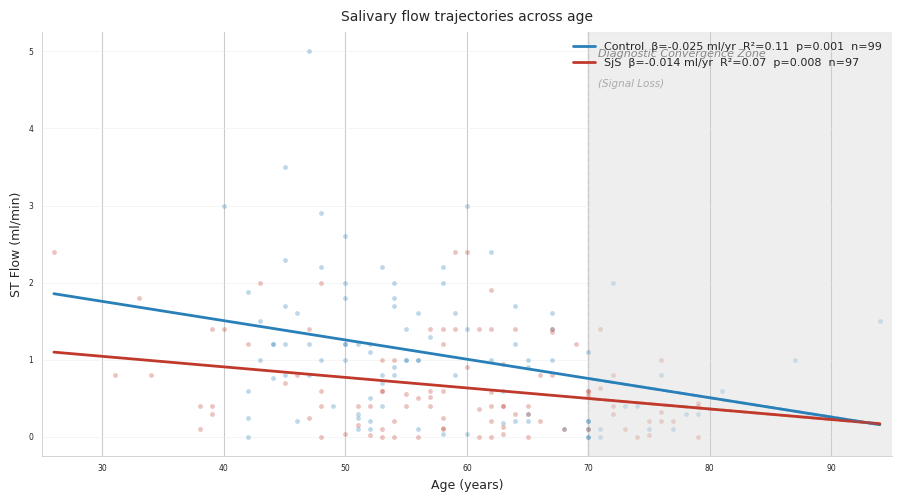

In [31]:
CONVERGENCE_AGE = 70

with publication_style():
    fig, ax = plt.subplots(figsize=(9, 5))
    fig.patch.set_facecolor("white")

    ax.axvspan(CONVERGENCE_AGE, age_flow["Age"].max() + 1, color="#EBEBEB", alpha=0.85, zorder=0)
    ax.axvline(CONVERGENCE_AGE, color="#CCCCCC", lw=1.0, ls="--", zorder=1)

    age_range = np.linspace(age_flow["Age"].min(), age_flow["Age"].max(), 300)
    age_range_late = age_range[age_range >= CONVERGENCE_AGE]
    for group, color, label in [(0, COLORS["control"], "Control"), (1, COLORS["sjogren"], "SjS")]:
        subset = age_flow[age_flow[TARGET] == group]
        fit = age_slopes[group]
        late = subset["Age"] > CONVERGENCE_AGE
        ax.scatter(subset.loc[~late, "Age"], subset.loc[~late, ST_FLOW], s=12, color=color, alpha=0.30, lw=0, zorder=3)
        ax.scatter(subset.loc[late, "Age"], subset.loc[late, ST_FLOW], s=12, color=color, alpha=0.18, lw=0, zorder=3)
        ax.plot(age_range, fit["slope"] * age_range + fit["intercept"], color=color, lw=2.0, zorder=4,
                label=(f"{label}  β={fit['slope']:.3f} ml/yr  R²={fit['r2']:.2f}  "
                       f"p={fit['p_value']:.3f}  n={fit['n']}"))
        ax.plot(age_range_late, fit["slope"] * age_range_late + fit["intercept"],
                color=color, lw=2.0, ls="--", alpha=0.35, zorder=5)

    y_lo, y_hi = ax.get_ylim()
    ax.text(CONVERGENCE_AGE + 0.8, y_hi - (y_hi - y_lo) * 0.04, "Diagnostic Convergence Zone",
            fontsize=8, color="#888888", style="italic", va="top", ha="left", zorder=6)
    ax.text(CONVERGENCE_AGE + 0.8, y_hi - (y_hi - y_lo) * 0.11, "(Signal Loss)",
            fontsize=7.5, color="#AAAAAA", style="italic", va="top", ha="left", zorder=6)

    ax.set_xlim(age_flow["Age"].min() - 1, age_flow["Age"].max() + 1)
    ax.set_ylim(y_lo, y_hi)
    ax.set_xlabel("Age (years)", fontsize=9)
    ax.set_ylabel("ST Flow (ml/min)", fontsize=9)
    ax.set_title("Salivary flow trajectories across age", fontsize=10, pad=8)
    ax.yaxis.grid(True, lw=0.4, color="#EEEEEE", zorder=0)
    ax.set_axisbelow(True)
    hide_top_right_spines(ax)
    ax.legend(fontsize=8, frameon=False, loc="upper right")
    fig.tight_layout()

    save_figure(fig, "fig5_panel_C_alt")
    plt.show()

Saved figures\fig5_panel_E_waterfall.pdf / .png


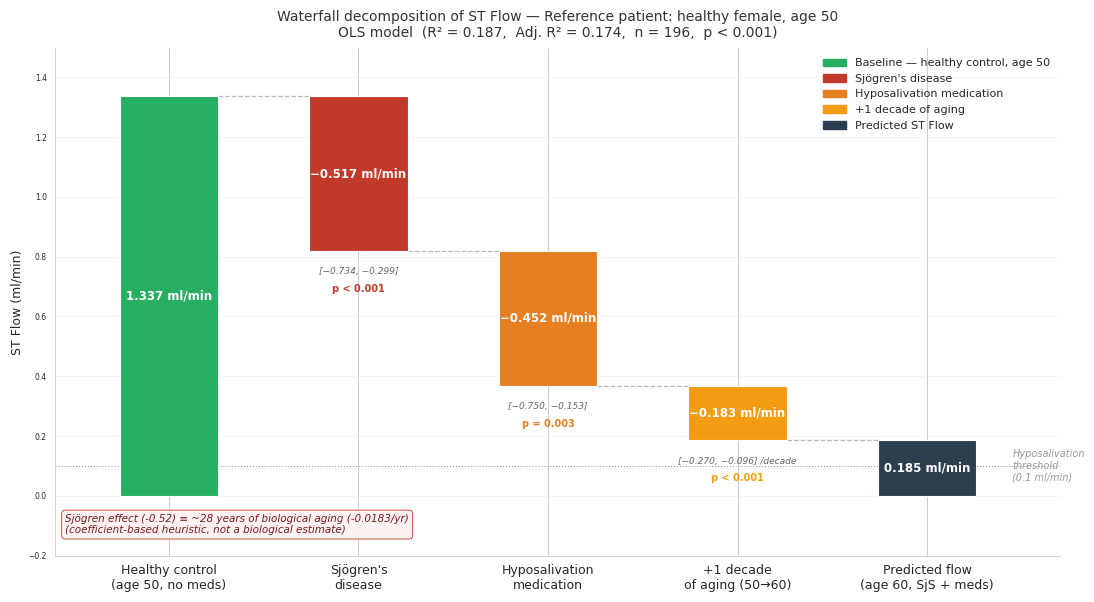

In [33]:
params, ci, pvals = flow_model.params, flow_model.conf_int(), flow_model.pvalues

# Baseline: predicted mean flow for a control of REF_AGE without medication (with its 95% CI)
baseline_design = pd.DataFrame({"const": [1.0], TARGET: [0], "Age": [REF_AGE], "Hyposalivation_med": [0]})
baseline_pred = flow_model.get_prediction(baseline_design).summary_frame(alpha=0.05).iloc[0]


def ci_text(lo, hi, suffix=""):
    return f"[{lo:.3f}, {hi:.3f}]{suffix}".replace("-", "−")


steps = [
    dict(label=f"Healthy control\n(age {REF_AGE}, no meds)", value=baseline_pred["mean"], kind="base",
         ci=ci_text(baseline_pred["mean_ci_lower"], baseline_pred["mean_ci_upper"]),
         p=None, color="#27AE60"),
    dict(label="Sjögren's\ndisease", value=params[TARGET], kind="neg",
         ci=ci_text(*ci.loc[TARGET]), p=format_p(pvals[TARGET]), color="#C0392B"),
    dict(label="Hyposalivation\nmedication", value=params["Hyposalivation_med"], kind="neg",
         ci=ci_text(*ci.loc["Hyposalivation_med"]), p=format_p(pvals["Hyposalivation_med"]), color="#E67E22"),
    dict(label=f"+1 decade\nof aging ({REF_AGE}→{REF_AGE + 10})", value=params["Age"] * 10, kind="neg",
         ci=ci_text(*(ci.loc["Age"] * 10), " /decade"), p=format_p(pvals["Age"]), color="#F39C12"),
    dict(label=f"Predicted flow\n(age {REF_AGE + 10}, SjS + meds)", value=None, kind="total", color="#2C3E50"),
]

running, bottoms, heights = 0.0, [], []
for step in steps:
    if step["kind"] == "base":
        bottoms.append(0)
        heights.append(step["value"])
        running = step["value"]
    elif step["kind"] == "total":
        bottoms.append(0)
        heights.append(running)
        step["value"] = running
    else:
        bottoms.append(running + step["value"])
        heights.append(abs(step["value"]))
        running += step["value"]

with publication_style():
    fig, ax = plt.subplots(figsize=(11, 6))
    fig.patch.set_facecolor("white")
    x, bar_w = np.arange(len(steps)), 0.52

    for i, (step, bottom, height) in enumerate(zip(steps, bottoms, heights)):
        ax.bar(x[i], height, bottom=bottom, width=bar_w, color=step["color"],
               edgecolor="white", linewidth=0.8, zorder=3)
        text = f"{step['value']:.3f} ml/min" if step["kind"] != "neg" else f"−{abs(step['value']):.3f} ml/min"
        ax.text(x[i], bottom + height / 2, text, ha="center", va="center",
                fontsize=8.5, fontweight="bold", color="white", zorder=4)
        if step.get("ci"):
            ax.text(x[i], bottom - 0.055, step["ci"], ha="center", va="top", fontsize=6.5,
                    color="#666666", style="italic")
        if step.get("p"):
            ax.text(x[i], bottom - 0.110, step["p"], ha="center", va="top", fontsize=7,
                    color=step["color"], fontweight="bold")

    for i in range(len(steps) - 1):
        if steps[i]["kind"] == "total":
            continue
        y_conn = bottoms[i] + heights[i] if steps[i]["kind"] == "base" else bottoms[i]
        ax.plot([x[i] + bar_w / 2, x[i + 1] - bar_w / 2], [y_conn, y_conn],
                color="#BBBBBB", lw=0.9, ls="--", zorder=2)

    ax.axhline(HYPOSALIVATION_THRESHOLD, color="#999999", lw=0.8, ls=":", zorder=1)
    ax.text(x[-1] + 0.45, HYPOSALIVATION_THRESHOLD,
            f"Hyposalivation\nthreshold\n({HYPOSALIVATION_THRESHOLD} ml/min)",
            va="center", fontsize=7, color="#999999", style="italic")

    ax.set_xlim(-0.6, len(steps) - 0.3)
    ax.set_ylim(min(bottoms) - 0.20, max(b + h for b, h in zip(bottoms, heights)) * 1.12)
    ax.set_xticks(x)
    ax.set_xticklabels([s["label"] for s in steps], fontsize=9)
    ax.set_ylabel("ST Flow (ml/min)", fontsize=9)
    ax.yaxis.grid(True, lw=0.4, color="#EEEEEE", zorder=0)
    ax.set_axisbelow(True)
    hide_top_right_spines(ax)

    ax.legend(handles=[mpatches.Patch(color=s["color"], label=lbl) for s, lbl in zip(steps, [
        f"Baseline — healthy control, age {REF_AGE}", "Sjögren's disease", "Hyposalivation medication",
        "+1 decade of aging", "Predicted ST Flow"])], fontsize=8, frameon=False, loc="upper right")

    ax.text(0.01, 0.04,
            f"Sjögren effect ({params[TARGET]:.2f}) ≡ ~{age_equivalent_years:.0f} years of biological aging "
            f"({params['Age']:.4f}/yr)\n(coefficient-based heuristic, not a biological estimate)",
            transform=ax.transAxes, ha="left", va="bottom", fontsize=7.5, color="#7A1A1A", style="italic",
            bbox=dict(boxstyle="round,pad=0.35", facecolor="#FDF2F2", edgecolor="#C0392B", lw=0.6))
    ax.set_title(
        f"Waterfall decomposition of ST Flow — Reference patient: healthy female, age {REF_AGE}\n"
        f"OLS model  (R² = {flow_model.rsquared:.3f},  Adj. R² = {flow_model.rsquared_adj:.3f},  "
        f"n = {int(flow_model.nobs)},  {format_p(flow_model.f_pvalue)})",
        fontsize=10, pad=8, color="#333333")
    fig.tight_layout()

    save_figure(fig, "fig5_panel_E_waterfall")
    plt.show()